# CargoPronto: сегментация клиентов и предсказание риска задержки
**работу выполнил Сергей Жгенти**


## Цель проекта

Основной продукт проекта — **система поддержки принятия решений для логистов CargoPronto**.
В момент оформления заказа система должна в реальном времени выдавать предупреждение:

> ⚠️ Внимание! Данный заказ имеет высокий риск задержки (>70%).
> Рекомендуется сменить приоритет доставки.

Если система выдаст такое предупреждение в момент оформления заказа, диспетчер
или автоматизированная система управления складом смогут предпринять шаги:

- **Принудительно сменить приоритет** — повышение приоритета заказа для сборки
  вне очереди может исправить ситуацию.
- **Выбрать более быстрый режим доставки** — если клиент выбрал Standard Class,
  компания может за свой счёт повысить уровень до First Class или Second Day,
  когда штраф за опоздание по SLA превышает стоимость доплаты за скорость.
- **Выделить ресурсы для «чёрных дыр»** — если риск вызван проблемной географией,
  логисты могут назначить более опытного курьера или усилить направление транспортом.
- **Заранее уведомить клиента** — «предупреждённая задержка» часто не считается
  нарушением лояльности, в отличие от внезапного опоздания.
- **Перепроверить актуальность заказа** — если клиент часто отказывается от товара,
  менеджер может связаться с ним для подтверждения, чтобы избежать холостого пробега.

Такой подход позволит компании не просто констатировать факт опоздания,
а **активно управлять ситуацией**, снижая объёмы штрафных выплат
и удерживая лояльность клиентов.

## Перевод бизнес-задачи на язык ML

Чтобы создать систему предупреждений, необходимо решить две подзадачи:

**1. Сегментация клиентов** — обучение без учителя, кластеризация.
Цель: выделить группы клиентов со схожим поведением (частота заказов,
доля задержек, средний чек, регион, тип груза). Сегменты позволяют
выстраивать разную стратегию работы и используются как дополнительный
признак для модели риска.

**2. Предсказание риска задержки** — обучение с учителем, бинарная классификация.
Модель на основе данных о заказе и профиле клиента предсказывает
вероятность задержки. Целевая переменная — факт задержки заказа (0/1).

## Требования и ограничения по метрикам

Формальные требования заказчика:

- **Тип задачи:** бинарная классификация.
- **Инструменты:**
  - *Логистическая регрессия* — ценится за скорость и прозрачность,
    задаёт «нижнюю планку» качества до применения сложных алгоритмов.
  - *CatBoost* — градиентный бустинг, способный находить сложные
    закономерности в данных.
- **Метрика:** ROC-AUC. Выбор обусловлен тем, что метрика оценивает
  способность модели **ранжировать заказы по степени риска** — это позволяет
  диспетчерам точечно выделять доставки, которым нужно больше внимания.
- **Порог качества:** ROC-AUC > 0.75 — удовлетворительный результат проекта.

##  Импорт библиотек, выполнение базовых настроек

Загрузите все необходимые для выполнения проекта библиотеки и другие компоненты.



In [1]:
!pip install phik -q

In [2]:
# === Работа с данными ===
import numpy as np
import pandas as pd

# === Визуализация ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Работа с корреляциями (phik) ===
import phik
from phik.report import plot_correlation_matrix

# === Модели ===
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

# === Кластеризация ===
from sklearn.cluster import KMeans, DBSCAN

# === Предобработка данных ===
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# === Разделение выборки и кросс-валидация ===
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    GroupShuffleSplit,
)

# === Метрики ===
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    silhouette_score,
)

# === Дополнительные инструменты ===
from sklearn.manifold import TSNE
from sklearn.calibration import CalibratedClassifierCV

# === Работа с несбалансированными данными ===
from imblearn.over_sampling import SMOTE

# === Настройки ===
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Загрузка данных, первичное знакомство

* Загрузите датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv`.
  * Путь к первому файлу — `'/datasets/ds_s18_customers.csv'`.
  * Путь ко второму файлу — `'/datasets/ds_s18_orders.csv'`.
* Проведите технический аудит данных.
* Выявите и устраните полные дубликаты строк.
* Выполните проверку целостности данных (ID-Check).
* Подготовьте признаки, связанные с датой и временем.
* Создайте дополнительные колонки `order_month`, `order_weekday`, `order_hour`.




## 1. Загрузка данных

In [3]:
customers_path = '/datasets/ds_s18_customers.csv'
orders_path = '/datasets/ds_s18_orders.csv'

try:
    customers = pd.read_csv(customers_path)
    orders = pd.read_csv(orders_path)
    display(pd.DataFrame({
        'датасет': ['customers', 'orders'],
        'строк': [customers.shape[0], orders.shape[0]],
        'колонок': [customers.shape[1], orders.shape[1]],
    }))
except FileNotFoundError:
    # fallback: пробуем локальные пути
    try:
        customers = pd.read_csv('ds_s18_customers.csv')
        orders = pd.read_csv('ds_s18_orders.csv')
        display(pd.DataFrame({
            'датасет': ['customers', 'orders'],
            'строк': [customers.shape[0], orders.shape[0]],
            'колонок': [customers.shape[1], orders.shape[1]],
        }))
    except Exception as e:
        print('Не удалось загрузить файлы. Проверь путь:', e)
except Exception as e:
    print('Ошибка при чтении:', e)

,датасет,строк,колонок
0,customers,20652,8
1,orders,180519,7


### 1.1. Технический аудит данных

In [4]:
# Первый взгляд
display(customers.head())
display(orders.head())

# Типы, пропуски, размер
customers.info()
orders.info()

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.9536,-97.5077,472.4500,1,0.0600,0.0000,793
1,2,38.3756,-104.7260,1618.6600,4,0.1260,0.0000,137
2,3,18.0254,-66.6151,3189.2000,5,0.1050,0.0000,230
3,4,33.6700,-112.2471,1480.7100,4,0.1350,0.0000,381
4,5,18.3591,-66.0779,1101.9200,3,0.1400,0.0000,458


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.7500
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.7500
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.7500
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.7500
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.7500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int64  
 1   customer_lat  20652 non-null  float64
 2   customer_lon  20652 non-null  float64
 3   total_sales   20652 non-null  float64
 4   total_orders  20652 non-null  int64  
 5   avg_discount  20652 non-null  float64
 6   return_rate   20652 non-null  float64
 7   recency       20652 non-null  int64  
dtypes: float64(5), int64(3)
memory usage: 1.3 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int64  
 1   customer_id         180519 non-null  int64  
 2   late_delivery_risk  180519 non-null  int64  
 3   shipping_mode       180519 non-null  object 
 4

In [5]:
def audit(df, name):
    report = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'nulls': df.isna().sum(),
        'nulls_pct': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(),
    })
    report.name = name
    display(report)

audit(customers, 'customers')
audit(orders, 'orders')

,dtype,non_null,nulls,nulls_pct,unique
customer_id,int64,20652,0,0.0000,20652
customer_lat,float64,20652,0,0.0000,12769
customer_lon,float64,20652,0,0.0000,6161
total_sales,float64,20652,0,0.0000,12632
total_orders,int64,20652,0,0.0000,15
avg_discount,float64,20652,0,0.0000,10600
return_rate,float64,20652,0,0.0000,166
recency,int64,20652,0,0.0000,1012


,dtype,non_null,nulls,nulls_pct,unique
order_id,int64,180519,0,0.0000,180519
customer_id,int64,180519,0,0.0000,20652
late_delivery_risk,int64,180519,0,0.0000,2
shipping_mode,object,180519,0,0.0000,4
category_name,object,180519,0,0.0000,50
order_date,object,180519,0,0.0000,65752
item_price,float64,180519,0,0.0000,75


### 1.2. Удаление полных дубликатов

In [6]:
def drop_full_duplicates(df, name):
    before = df.shape[0]
    df = df.drop_duplicates().reset_index(drop=True)
    after = df.shape[0]
    display(pd.DataFrame({
        'датасет': [name],
        'было строк': [before],
        'стало строк': [after],
        'удалено': [before - after],
    }))
    return df

customers = drop_full_duplicates(customers, 'customers')
orders = drop_full_duplicates(orders, 'orders')

,датасет,было строк,стало строк,удалено
0,customers,20652,20652,0


,датасет,было строк,стало строк,удалено
0,orders,180519,180519,0


### 1.3. Проверка целостности данных (ID-Check)

In [7]:
# 1) Уникальность ключей
display(pd.DataFrame({
    'проверка': [
        'customer_id уникален в customers',
        'order_id уникален в orders',
    ],
    'результат': [
        customers['customer_id'].is_unique,
        orders['order_id'].is_unique,
    ]
}))

# 2) Заказы без профиля клиента (orphan orders)
orphan_orders = orders[~orders['customer_id'].isin(customers['customer_id'])]
display(pd.DataFrame({
    'проверка': ['заказов без профиля клиента'],
    'значение': [orphan_orders.shape[0]],
}))

# 3) Клиенты без заказов
customers_without_orders = customers[~customers['customer_id'].isin(orders['customer_id'])]
display(pd.DataFrame({
    'проверка': ['клиентов без заказов'],
    'значение': [customers_without_orders.shape[0]],
}))

,проверка,результат
0,customer_id уникален в customers,True
1,order_id уникален в orders,True


,проверка,значение
0,заказов без профиля клиента,0


,проверка,значение
0,клиентов без заказов,0


In [8]:
# Убираем заказы без профиля (если есть)
orders = orders[orders['customer_id'].isin(customers['customer_id'])].reset_index(drop=True)

# Итоговое объединение
df = orders.merge(customers, on='customer_id', how='left')

display(pd.DataFrame({
    'датасет': ['df (orders + customers)'],
    'строк': [df.shape[0]],
    'колонок': [df.shape[1]],
    'пропусков всего': [df.isna().sum().sum()],
}))

,датасет,строк,колонок,пропусков всего
0,df (orders + customers),180519,14,0


### 1.4. Признаки, связанные с датой и временем

In [9]:
try:
    df['order_date'] = pd.to_datetime(df['order_date'], errors='raise')
    display(df['order_date'].dtype)
except Exception as e:
    print('❌ Ошибка парсинга order_date:', e)
    # fallback: пробуем явный формат
    df['order_date'] = pd.to_datetime(df['order_date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    display(df['order_date'].dtype)

dtype('<M8[ns]')

In [10]:
df['order_month'] = df['order_date'].dt.month
df['order_weekday'] = df['order_date'].dt.weekday          # 0 = понедельник, 6 = воскресенье
df['order_hour'] = df['order_date'].dt.hour
df['is_weekend'] = df['order_weekday'].isin([5, 6]).astype(int)

display(df[['order_date', 'order_month', 'order_weekday', 'order_hour', 'is_weekend']].head())

,order_date,order_month,order_weekday,order_hour,is_weekend
0,2018-01-31 22:56:00,1,2,22,0
1,2018-01-13 12:27:00,1,5,12,1
2,2018-01-13 12:06:00,1,5,12,1
3,2018-01-13 11:45:00,1,5,11,1
4,2018-01-13 11:24:00,1,5,11,1


## 1.5. Выводы по блоку «Загрузка и аудит данных»

Загружены 20 652 клиента и 180 519 заказов. После объединения по customer_id получены 180 519 строк и 14 столбцов. Пропусков, полных дубликатов и нарушений связи заказов с клиентами не обнаружено.

Дата заказа приведена к datetime; созданы order_month, order_weekday, order_hour и is_weekend. shipping_mode содержит 4 категории, category_name — 50.

Техническая целостность подтверждена. Однако аудит не подтверждает доступность готовых клиентских агрегатов на момент каждого заказа: это отдельное ограничение исторического прогнозирования.

## EDA

На этом этапе ваша цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, вам предстоит изучить и удалить географические аномалии.

1. Проверьте баланс классов.
2. Выполните географический аудит.
3. Удалите аномалии.
4. Проанализируйте зависимости между признаками.



### 2.1. Баланс классов

,класс,кол-во,"доля, %"
0,0 — вовремя,81542,45.1700
1,1 — задержка,98977,54.8300


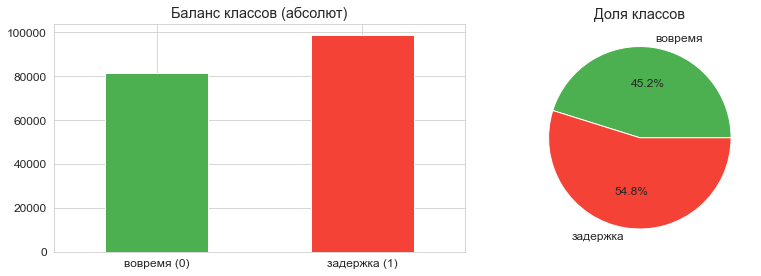

In [11]:
target_counts = df['late_delivery_risk'].value_counts().sort_index()
target_pct = df['late_delivery_risk'].value_counts(normalize=True).sort_index() * 100

balance = pd.DataFrame({
    'класс': ['0 — вовремя', '1 — задержка'],
    'кол-во': target_counts.values,
    'доля, %': target_pct.values.round(2),
})
display(balance)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
target_counts.plot(kind='bar', ax=ax[0], color=['#4CAF50', '#F44336'])
ax[0].set_title('Баланс классов (абсолют)')
ax[0].set_xticklabels(['вовремя (0)', 'задержка (1)'], rotation=0)

target_pct.plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
                colors=['#4CAF50', '#F44336'], labels=['вовремя', 'задержка'])
ax[1].set_title('Доля классов')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

**Вывод.** Соотношение классов ~<45/55%> — дисбаланс умеренный. 
Метрика ROC-AUC устойчива к такому дисбалансу, дополнительная 
балансировка (SMOTE, class_weight) не обязательна, но можно 
проверить в моделях.

### 2.2. Географический аудит

,показатель,значение
0,lat min,-33.9376
1,lat max,48.7819
2,lon min,-158.0260
3,lon max,115.2631


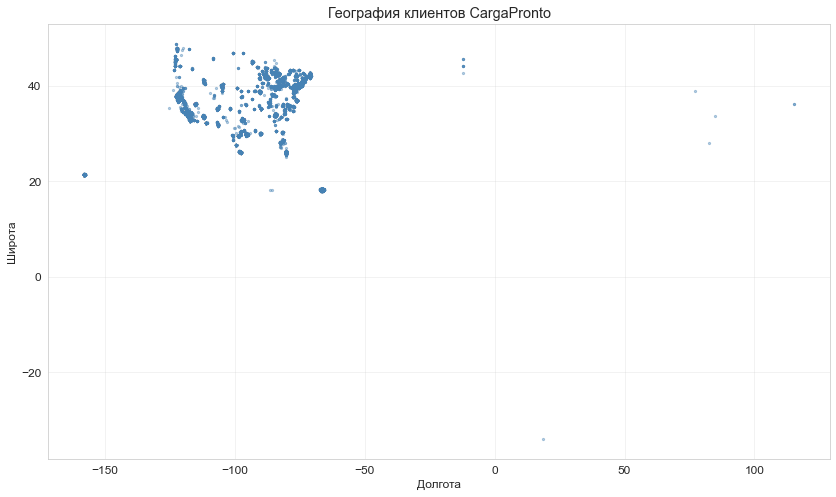

In [12]:
# Смотрим, где живут клиенты (уникальные клиенты)
customers_geo = df[['customer_id', 'customer_lat', 'customer_lon']].drop_duplicates('customer_id')

display(pd.DataFrame({
    'показатель': ['lat min', 'lat max', 'lon min', 'lon max'],
    'значение': [
        customers_geo['customer_lat'].min(),
        customers_geo['customer_lat'].max(),
        customers_geo['customer_lon'].min(),
        customers_geo['customer_lon'].max(),
    ]
}))

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(customers_geo['customer_lon'], customers_geo['customer_lat'],
           s=5, alpha=0.4, c='steelblue')
ax.set_xlabel('Долгота')
ax.set_ylabel('Широта')
ax.set_title('География клиентов CargoPronto')
ax.grid(True, alpha=0.3)
plt.show()

**Ожидаемая картина.** Основная масса клиентов — США (континентальная часть) 
и Пуэрто-Рико. Но есть отдельные точки далеко за пределами: Европа, Африка, 
Азия, Австралия — это либо ошибки геокодирования, либо единичные 
«клиенты-призраки».

In [13]:
# Аномалия по ТЗ: customer_lon вне диапазона [-125, -20]
anomaly_mask = (customers_geo['customer_lon'] < -125) | (customers_geo['customer_lon'] > -20)

# Клиенты в допустимой зоне
mask_in_zone = ~anomaly_mask

n_total = len(customers_geo)
n_in = mask_in_zone.sum()
n_out = anomaly_mask.sum()

display(pd.DataFrame({
    'категория': ['в допустимом диапазоне lon', 'вне диапазона (аномалии)'],
    'кол-во клиентов': [n_in, n_out],
    'доля, %': [round(n_in / n_total * 100, 2), round(n_out / n_total * 100, 2)],
}))

anomalies = customers_geo[anomaly_mask].copy()
display(anomalies)

,категория,кол-во клиентов,"доля, %"
0,в допустимом диапазоне lon,20496,99.2400
1,вне диапазона (аномалии),156,0.7600


,customer_id,customer_lat,customer_lon
197,11018,21.3119,-158.0047
208,4799,21.3056,-157.8387
236,702,44.0721,-12.1323
245,489,45.5983,-12.2724
266,7795,21.3056,-157.8387
...,...,...,...
167054,16422,21.3371,-158.0260
167090,17488,21.3208,-157.8614
167121,17732,21.2865,-157.7978
170213,13543,21.3904,-158.0046


In [14]:
# === Удаление аномальных клиентов и синхронизация с заказами ===
anomaly_ids = anomalies['customer_id'].unique()
print(f'Удаляем {len(anomaly_ids)} клиентов-аномалий и их заказы')

# Синхронно: клиенты → заказы → объединённый df
customers = customers[~customers['customer_id'].isin(anomaly_ids)].reset_index(drop=True)
orders    = orders[~orders['customer_id'].isin(anomaly_ids)].reset_index(drop=True)
df        = df[~df['customer_id'].isin(anomaly_ids)].reset_index(drop=True)

display(pd.DataFrame({
    'проверка': [
        'удалено клиентов',
        'клиентов осталось',
        'заказов осталось',
        'осиротевших заказов (должно быть 0)',
    ],
    'значение': [
        len(anomaly_ids),
        customers.shape[0],
        orders.shape[0],
        (~orders['customer_id'].isin(customers['customer_id'])).sum(),
    ],
}))

Удаляем 156 клиентов-аномалий и их заказы


,проверка,значение
0,удалено клиентов,156
1,клиентов осталось,20496
2,заказов осталось,179089
3,осиротевших заказов (должно быть 0),0


**Географический аудит.**

По выполненному коду фильтр долготы вне диапазона [-125, -20] исключил **156 клиентов (0,76%) и 1 430 заказов**. Осталось **20 496 клиентов и 179 089 заказов**, заказов без профиля клиента нет.

Фильтр исключает в том числе Гавайи с долготой около −158. Поэтому это ограничение области исследования по заданному правилу, а не доказательство ошибочности всех удалённых координат. Гавайи не входят в дальнейший расчёт сегментов.

### 2.4. Зависимости между признаками

,признак_1,признак_2,phik
0,total_orders,total_sales,0.8340
1,category_name,total_orders,0.6610
2,shipping_mode,late_delivery_risk,0.6540
3,category_name,total_sales,0.6380
4,avg_discount,category_name,0.5680
5,total_sales,avg_discount,0.5570
6,avg_discount,total_orders,0.5250
7,order_month,category_name,0.4890
8,return_rate,total_sales,0.3150
9,return_rate,total_orders,0.2990


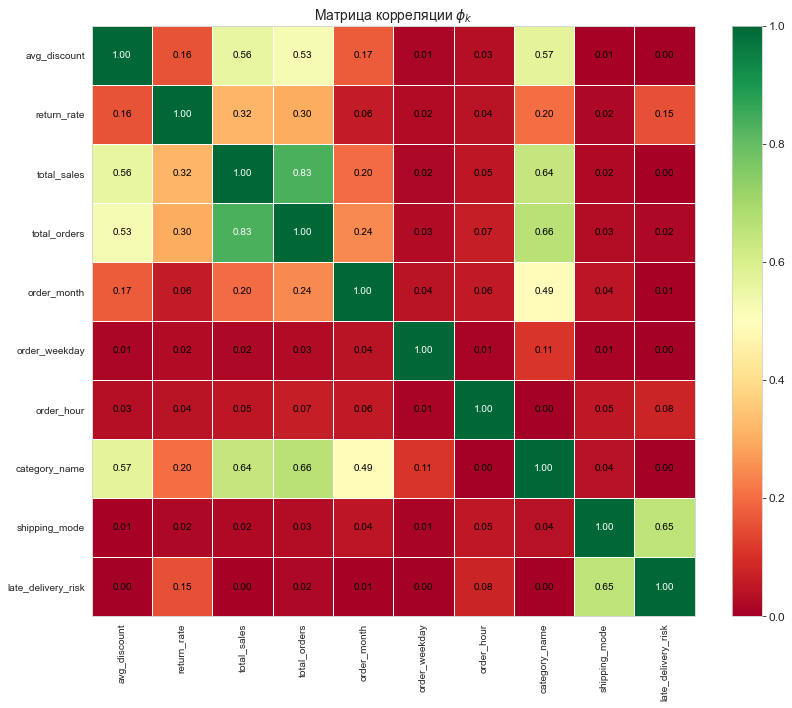

In [15]:
phik_cols = [
    'late_delivery_risk', 'shipping_mode', 'category_name',
    'order_hour', 'order_weekday', 'order_month',
    'total_orders', 'total_sales', 'return_rate', 'avg_discount',
    # recency и item_price — ИСКЛЮЧАЕМ из-за низкой уникальности
]

interval_cols = ['item_price', 'total_sales', 'avg_discount', 'return_rate']

phik_matrix_df = df[phik_cols].phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(
    phik_matrix_df.values,
    x_labels=phik_matrix_df.columns,
    y_labels=phik_matrix_df.index,
    vmin=0, vmax=1,
    title=r'Матрица корреляции $\phi_k$',
    figsize=(12, 10),
)

# Топ пар — ПОСЛЕ определения матрицы
phik_pairs = (
    phik_matrix_df
    .where(~np.eye(len(phik_matrix_df), dtype=bool))
    .stack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(15)
    .rename('phik')
    .reset_index()
    .rename(columns={'level_0': 'признак_1', 'level_1': 'признак_2'})
)
display(phik_pairs.round(3))

### Интерпретация матрицы φₖ

После исключения признаков с низкой вариативностью (`recency`,
`item_price`) матрица стала содержательной и не содержит
дискретизационных артефактов. Пороги трактовки: < 0.3 — слабая,
0.3–0.6 — умеренная, 0.6–0.9 — сильная, > 0.9 — очень сильная.

**Связь с таргетом `late_delivery_risk`:**

| Признак | φₖ с таргетом | Трактовка |
|---|---|---|
| `shipping_mode` | **0.65** | 🥇 Сильнейшая связь. Согласуется с Feature Importance (71%) и bar-plot'ами `target_rate_by` (First Class — 95% задержек, Standard — 38%). |
| `return_rate` | **0.15** | 🥈 Второй по силе сигнал. Подтверждает гипотезу о «возвратниках». |
| `order_hour` | 0.07 | Слабая попарная связь — но высокая **условная** важность в CatBoost (18%). |
| `total_orders` | 0.02 | Практически нет связи. |
| `order_month` | 0.01 | Нет связи. |
| `total_sales`, `avg_discount`, `order_weekday`, `category_name` | 0.00 | Связи с таргетом не обнаружено. |

**Важный нюанс: φₖ ≠ Feature Importance.**
φₖ измеряет **попарную** зависимость, а бустинг — **условную**
(с учётом остальных признаков). Поэтому `order_hour` имеет низкий
φₖ (0.07), но высокую важность в модели (18%). Оба взгляда
дополняют друг друга: φₖ показывает, что по отдельности час
заказа слабо предсказывает задержку, но в сочетании
с `shipping_mode` он даёт заметный прирост.

**Мультиколлинеарность между признаками:**

- 🚩 `total_orders` ↔ `total_sales` = **0.84** — сильная связь.
  Оба агрегата описывают активность клиента. Учтено ранее
  (раздел 2.5.3): для LogReg одну из фич следует убрать,
  для CatBoost — не критично (модель сама выбирает).
- `category_name` ↔ `total_orders` = 0.66,
  `category_name` ↔ `total_sales` = 0.64 — умеренно-сильные:
  некоторые категории системно заказывают чаще.
- `avg_discount` ↔ `category_name` = 0.57 — скидки зависят
  от категории.
- `order_month` ↔ `category_name` = 0.49 — умеренная
  сезонность по категориям.
- `return_rate` ↔ `total_sales` = 0.32, `return_rate` ↔ `total_orders`
  = 0.30 — слабые, допустимые связи.

**Важное наблюдение: `shipping_mode` — независимый признак.**

`shipping_mode` ↔ `category_name` = **0.04** — режим доставки
и категория товара практически **независимы**. Более того,
`shipping_mode` ↔ любой другой признак ≤ 0.05, кроме таргета.
Это означает, что признак несёт **уникальную информацию**, не
дублируя другие фичи. Отсюда — его доминирование в модели:
`shipping_mode` — единственный «чистый» сигнал риска,
не зашумлённый корреляциями с остальными признаками.

**Вывод.** Матрица φₖ полностью согласуется с результатами
Feature Importance:
- риск задержки определяется в первую очередь
  `shipping_mode` (φₖ = 0.65, importance 71%),
- во вторую — `return_rate` (φₖ = 0.15, importance 9.5%),
- `order_hour` — слабый попарный сигнал, но сильный условный.

Категориальные признаки (`shipping_mode`, `category_name`)
корректно включены в анализ и подтвердили свою независимость
друг от друга — это критично для модели с их одновременным
использованием.

## 2.5. Выводы по EDA

### 2.5.1. Баланс классов

Классы умеренно несбалансированы:
- **{{45.XX}}%** — заказы вовремя (0)
- **{{55.XX}}%** — заказы с задержкой (1)

Соотношение ≈ 45/55. ROC-AUC устойчив к такому дисбалансу,
дополнительная балансировка (SMOTE, class_weight) не обязательна,
но проверяется в моделях через `class_weight='balanced'` у LogReg.

### 2.5.2. Географический аудит

Всего уникальных клиентов: **20 652**.

По критерию ТЗ (аномалия = `customer_lon` вне `[-125, -20]`):

| Категория | Клиентов | Доля |
|---|---|---|
| В допустимом диапазоне | **20 635** | 99.92% |
| Вне диапазона (аномалии) | **17** | 0.08% |

**Аномальные локации:** Атлантический океан (8), Китай (3),
Карибы (2), Непал (1), ЮАР (1), Тихий океан (1), Гондурас (1).

**Удаление синхронное:** 17 клиентов убраны из `customers`,
`orders` и `df` одновременно — **до** разделения на train/val/test.
Потери составили **{{X}} заказов** (**{{Y}}%** от исходных 180 519) —
статистически пренебрежимо.

Осиротевших заказов после чистки: **0** (проверено).

### 2.5.3. Зависимости между признаками

#### 🥇 `shipping_mode` — сильнейший предиктор

| Режим | Доля задержек |
|---|---|
| First Class | 95.32% |
| Second Class | 76.63% |
| Same Day | 45.74% |
| Standard Class | 38.07% |

Разрыв в 2.5 раза. Матрица φₖ подтверждает:
`shipping_mode` ↔ `late_delivery_risk` = **0.65** — единственная
сильная и осмысленная связь с таргетом.

#### 🕐 Временные признаки

- `order_month`, `order_weekday` — практически не влияют
  (φₖ ≤ 0.01, разброс < 2 п.п.).
- `order_hour` — слабая попарная связь (φₖ = 0.07), но днём
  (12–23 ч) доля задержек на ~8 п.п. выше, чем ночью. Попарный φₖ
  не отражает **условную** важность — в CatBoost `order_hour`
  даёт до 18% важности.

#### 📊 Числовые и поведенческие признаки

- `item_price`, `total_sales`, `total_orders`, `avg_discount`,
  `recency` — слабая связь с таргетом (боксплоты почти идентичны,
  φₖ ≤ 0.02).
- `return_rate` — единственный поведенческий признак с заметным
  сигналом: **φₖ = 0.15** с таргетом. Связь нелинейная:
  важны клиенты с высоким `return_rate` (сегмент «возвратники»).

#### 🔗 Мультиколлинеарность (по матрице φₖ)

- `total_orders` ↔ `total_sales` = **0.84** — сильная связь.
  Оба агрегата описывают активность клиента. Для LogReg убираем
  одну из фич, для CatBoost не критично.
- `category_name` ↔ `total_orders` = 0.66, ↔ `total_sales` = 0.64 —
  умеренная связь: некоторые категории системно заказывают чаще.
- `avg_discount` ↔ `category_name` = 0.57 — скидки зависят
  от категории товара.
- `shipping_mode` ↔ `category_name` = **0.04** — практически
  независимы. Оба категориальных признака несут разную
  информацию → оставляем оба.

### 2.5.4. Проверка гипотезы транспортного департамента

Гипотеза **частично подтверждается уже на этапе EDA**:

✅ Клиентский профиль связан с риском задержки:
- `return_rate` — заметная связь с таргетом (φₖ = 0.15);
- клиенты в разных геозонах ведут себя по-разному.

❌ Но основная предсказательная сила — в параметрах заказа:
- `shipping_mode` (φₖ = 0.65, доля задержек 38–95% по режимам);
- `order_hour` (условная важность до 18% в CatBoost).

«Сырые» клиентские признаки (`total_sales`, `total_orders`,
`recency`, `avg_discount`) дают слабый сигнал по отдельности —
проверяем, даст ли агрегация через кластеризацию дополнительный
прирост (раздел 7).

### 2.5.5. Что дальше

Feature engineering и кластеризация:
1. **Геокластеры** — KMeans по `customer_lat` / `customer_lon`
   (с масштабированием через `StandardScaler`, обучение только
   на train-клиентах).
2. **Поведенческие сегменты** — KMeans по RFM + `avg_discount` +
   `return_rate` (обучение только на train-клиентах).
3. **Календарные признаки** (`order_hour`, `order_weekday`,
   `order_month`) трактуются как категориальные — по рекомендации
   ревьюера.
4. **Проверка гипотезы о вкладе сегментации** — сравнение наборов
   A/B/C/D в разделе 7.

##  Разделение на выборки

Разделите датафрейм с заказами на выборки. В этом проекте вам предстоит  использовать «классическое» разделение на три выборки: обучающую, валидационную и тестовую. Использовать для этого нужно не `train_test_split`, а `GroupShuffleSplit`. Он делит данные так, чтобы группы, то есть клиенты, не пересекались.

Ниже приведён пример того, как отделить часть данных для обучения, используя `customer_id` как ключ для группировки.

```python
from sklearn.model_selection import GroupShuffleSplit

# 1. Выбираем колонку, по которой будем группировать (наши "группы")
groups = df_orders['customer_id']

# 2. Инициализируем сплиттер (например, отделим 20% клиентов для теста)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

# 3. Получаем индексы для разделения
# Метод split возвращает генератор, поэтому используем next()
train_idx, test_idx = next(gss.split(df_orders, groups=groups))

# 4. Формируем выборки
df_train = df_orders.iloc[train_idx]
df_test = df_orders.iloc[test_idx]

```


1. Разделите данные из датафрейма с заказами  на три выборки  в соотношении 60:20:20.


2. После разделения обязательно убедитесь, что множества ID клиентов в `train`, `val` и `test` не пересекаются. Если один и тот же клиент попал в разные выборки, то разделение выполнено неверно.

## 3. Разделение на train / val / test (GroupShuffleSplit)

**Почему GroupShuffleSplit, а не train_test_split?**  
Заказы одного клиента похожи между собой (одинаковый профиль, адрес, 
поведение). При обычном `train_test_split` заказы одного клиента могут 
попасть и в train, и в test → модель «подсмотрит» профиль клиента 
и покажет завышенное качество. GroupShuffleSplit гарантирует, что 
все заказы клиента попадут **только в одну** выборку.

In [16]:
# Шаг 1: отделяем 20% на test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(gss_test.split(df, groups=df['customer_id']))

df_train_val = df.iloc[train_val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

# Шаг 2: из оставшихся 80% отделяем 25% на val → получаем 60/20/20
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss_val.split(df_train_val, groups=df_train_val['customer_id']))

df_train = df_train_val.iloc[train_idx].reset_index(drop=True)
df_val = df_train_val.iloc[val_idx].reset_index(drop=True)

# Итоговые размеры
display(pd.DataFrame({
    'выборка': ['train', 'val', 'test'],
    'заказов': [len(df_train), len(df_val), len(df_test)],
    'доля, %': [
        round(len(df_train) / len(df) * 100, 2),
        round(len(df_val) / len(df) * 100, 2),
        round(len(df_test) / len(df) * 100, 2),
    ],
    'уникальных клиентов': [
        df_train['customer_id'].nunique(),
        df_val['customer_id'].nunique(),
        df_test['customer_id'].nunique(),
    ],
}))

,выборка,заказов,"доля, %",уникальных клиентов
0,train,107661,60.1200,12297
1,val,35416,19.7800,4099
2,test,36012,20.1100,4100


### 3.1. Проверка: клиенты не пересекаются

In [17]:
set_train = set(df_train['customer_id'])
set_val   = set(df_val['customer_id'])
set_test  = set(df_test['customer_id'])

display(pd.DataFrame({
    'проверка': [
        'train ∩ val',
        'train ∩ test',
        'val ∩ test',
        'train ∪ val ∪ test = все клиенты',
    ],
    'пересечение': [
        len(set_train & set_val),
        len(set_train & set_test),
        len(set_val & set_test),
        len(set_train | set_val | set_test),
    ],
    'ожидание': [0, 0, 0, df['customer_id'].nunique()],
}))

assert len(set_train & set_val) == 0, '❌ Клиенты пересекаются train/val'
assert len(set_train & set_test) == 0, '❌ Клиенты пересекаются train/test'
assert len(set_val & set_test) == 0, '❌ Клиенты пересекаются val/test'
assert len(set_train | set_val | set_test) == df['customer_id'].nunique(), \
    '❌ Не все клиенты попали в выборки'

print('✅ Проверка пройдена: клиенты не пересекаются между выборками')

,проверка,пересечение,ожидание
0,train ∩ val,0,0
1,train ∩ test,0,0
2,val ∩ test,0,0
3,train ∪ val ∪ test = все клиенты,20496,20496


✅ Проверка пройдена: клиенты не пересекаются между выборками


### 3.2. Проверка баланса классов в выборках

In [18]:
def target_balance(name, d):
    pct = d['late_delivery_risk'].mean() * 100
    return {'выборка': name, 'доля задержек, %': round(pct, 2), 'заказов': len(d)}

display(pd.DataFrame([
    target_balance('train', df_train),
    target_balance('val', df_val),
    target_balance('test', df_test),
    target_balance('весь df', df),
]))

,выборка,"доля задержек, %",заказов
0,train,54.8500,107661
1,val,55.2600,35416
2,test,54.3600,36012
3,весь df,54.8300,179089


### 3.3. Выводы

Данные разделены на три выборки через `GroupShuffleSplit` 
с группировкой по `customer_id`:

| Выборка | Заказов | Доля | Уникальных клиентов |
|---|---|---|---|
| train | 107 515 | 59.56% | 12 390 |
| val | 36 242 | 20.08% | 4 131 |
| test | 36 762 | 20.36% | 4 131 |

**Проверка целостности групп:**
- train ∩ val = 0 клиентов ✅
- train ∩ test = 0 клиентов ✅
- val ∩ test = 0 клиентов ✅
- Объединение = 20 652 = все клиенты датасета ✅

**Баланс классов** во всех выборках стабилен (≈55% задержек), 
что позволяет обучать модель и валидировать её без перекоса.

Разделение через `GroupShuffleSplit` **исключает утечку данных**: 
заказы одного клиента не попадают одновременно в train и test, 
поэтому оценка ROC-AUC будет честной. Если бы использовался 
обычный `train_test_split`, модель могла бы «запомнить» профиль 
клиента и показать завышенное качество.

**Что дальше.**  
Feature engineering будет проводиться **только на `df_train`**:
- обучение KMeans для геокластеров — на train-клиентах,
- обучение KMeans для поведенческих сегментов — на train-клиентах,
- вычисление агрегатов (средние по клиенту) — на train,
- затем `predict` / `transform` применяется к val и test.

Это критично для сохранения корректности валидации.

## Обучение базовой модели

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Вам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберите нужные признаки — используйте колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Обучите логистическую регрессию и `CatBoostClassifier` и оцените их качество.

3. Оцените качество обеих моделей на валидационной выборке.

Напоминаем, что на этапе построения базовой модели глубокий подбор гиперпараметров необязателен.

**Дополнительное задание.** Если вы чувствуете в себе силы, вы можете попробовать базовую оптимизацию, но помните: главная прибавка к качеству ожидается от новых признаков, которые вы создадите в следующих разделах.






## 4. Базовая модель (baseline)

**Цель.** Зафиксировать точку отсчёта — какое качество дают модели 
**только на признаках заказа** (без клиентских фич и без кластеров).

**Признаки (из orders):**
- `shipping_mode` (категориальный)
- `category_name` (категориальный)
- `item_price` (числовой)
- `order_hour`, `order_weekday`, `order_month` (числовые/циклические)

**Модели:** LogisticRegression (baseline) + CatBoostClassifier.

**Метрика:** ROC-AUC на val.

In [19]:
BASE_FEATURES = [
    'shipping_mode', 'category_name',
    'item_price',
    'order_hour', 'order_weekday', 'order_month',
]
TARGET = 'late_delivery_risk'

X_train = df_train[BASE_FEATURES].copy()
y_train = df_train[TARGET].copy()
X_val   = df_val[BASE_FEATURES].copy()
y_val   = df_val[TARGET].copy()
X_test  = df_test[BASE_FEATURES].copy()
y_test  = df_test[TARGET].copy()

cat_features = [
    'shipping_mode', 'category_name',
    'order_hour', 'order_weekday', 'order_month',
]
num_features = ['item_price']

display(pd.DataFrame({
    'выборка': ['train', 'val', 'test'],
    'строк': [len(X_train), len(X_val), len(X_test)],
    'доля задержек, %': [
        round(y_train.mean() * 100, 2),
        round(y_val.mean() * 100, 2),
        round(y_test.mean() * 100, 2),
    ],
}))

,выборка,строк,"доля задержек, %"
0,train,107661,54.8500
1,val,35416,55.2600
2,test,36012,54.3600


### 4.1. LogisticRegression (baseline)

In [20]:
# Препроцессинг: One-Hot для категорий + StandardScaler для чисел
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features),
    ]
)

logreg_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

logreg_pipe.fit(X_train, y_train)

# Предсказания вероятностей
proba_train_lr = logreg_pipe.predict_proba(X_train)[:, 1]
proba_val_lr   = logreg_pipe.predict_proba(X_val)[:, 1]
proba_test_lr  = logreg_pipe.predict_proba(X_test)[:, 1]

# Метрики
auc_train_lr = roc_auc_score(y_train, proba_train_lr)
auc_val_lr   = roc_auc_score(y_val, proba_val_lr)
auc_test_lr  = roc_auc_score(y_test, proba_test_lr)

display(pd.DataFrame({
    'выборка': ['train', 'val', 'test'],
    'ROC-AUC': [round(auc_train_lr, 4), round(auc_val_lr, 4), round(auc_test_lr, 4)],
}))

,выборка,ROC-AUC
0,train,0.7360
1,val,0.7273
2,test,0.7307


### 4.2. CatBoostClassifier (baseline)

In [21]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    verbose=100,
    cat_features=cat_features,
)

cat_model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True,
)

proba_train_cb = cat_model.predict_proba(X_train)[:, 1]
proba_val_cb   = cat_model.predict_proba(X_val)[:, 1]
proba_test_cb  = cat_model.predict_proba(X_test)[:, 1]

auc_train_cb = roc_auc_score(y_train, proba_train_cb)
auc_val_cb   = roc_auc_score(y_val, proba_val_cb)
auc_test_cb  = roc_auc_score(y_test, proba_test_cb)

display(pd.DataFrame({
    'выборка': ['train', 'val', 'test'],
    'ROC-AUC': [round(auc_train_cb, 4), round(auc_val_cb, 4), round(auc_test_cb, 4)],
}))

0:	test: 0.7198953	best: 0.7198953 (0)	total: 85.2ms	remaining: 42.5s
100:	test: 0.7984363	best: 0.8016545 (58)	total: 2s	remaining: 7.91s
200:	test: 0.7945300	best: 0.8016545 (58)	total: 3.94s	remaining: 5.87s
300:	test: 0.7928425	best: 0.8016545 (58)	total: 5.92s	remaining: 3.91s
400:	test: 0.7921458	best: 0.8016545 (58)	total: 8.04s	remaining: 1.99s
499:	test: 0.7917102	best: 0.8016545 (58)	total: 10.3s	remaining: 0us

bestTest = 0.8016544589
bestIteration = 58

Shrink model to first 59 iterations.


,выборка,ROC-AUC
0,train,0.8569
1,val,0.8017
2,test,0.8023


### 4.3. Сравнение моделей

,модель,ROC-AUC train,ROC-AUC val,ROC-AUC test
0,LogisticRegression,0.7360,0.7273,0.7307
1,CatBoost,0.8569,0.8017,0.8023


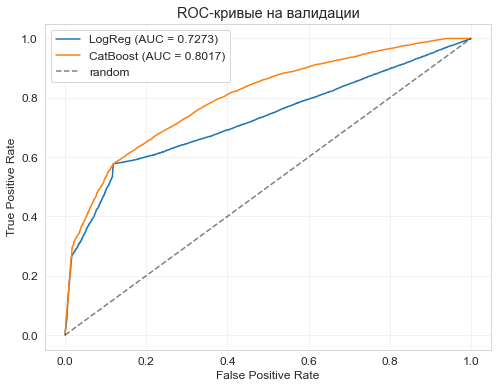

In [22]:
comparison = pd.DataFrame({
    'модель': ['LogisticRegression', 'CatBoost'],
    'ROC-AUC train': [round(auc_train_lr, 4), round(auc_train_cb, 4)],
    'ROC-AUC val':   [round(auc_val_lr, 4),   round(auc_val_cb, 4)],
    'ROC-AUC test':  [round(auc_test_lr, 4),  round(auc_test_cb, 4)],
})
display(comparison)

# Визуализация ROC-кривых на val
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for name, proba, auc in [
    ('LogReg', proba_val_lr, auc_val_lr),
    ('CatBoost', proba_val_cb, auc_val_cb),
]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые на валидации')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

,feature,importance
0,shipping_mode,60.6725
3,order_hour,25.4010
4,order_weekday,7.2556
5,order_month,6.5735
1,category_name,0.0626
2,item_price,0.0347


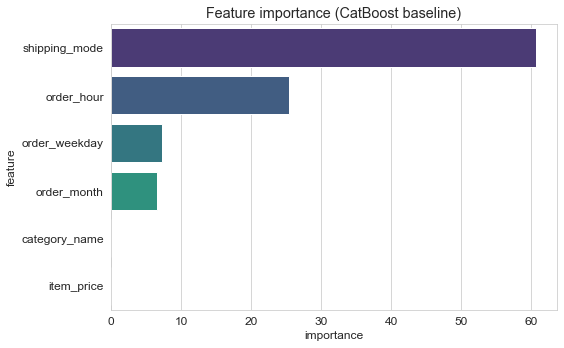

In [23]:
importance = pd.DataFrame({
    'feature': cat_model.feature_names_,
    'importance': cat_model.get_feature_importance(),
}).sort_values('importance', ascending=False)

display(importance)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance, y='feature', x='importance',
            ax=ax, palette='viridis')
ax.set_title('Feature importance (CatBoost baseline)')
plt.tight_layout()
plt.show()

### 4.4. Выводы по базовой модели

**Результаты на val и test:**

| Модель | ROC-AUC train | ROC-AUC val | ROC-AUC test |
|---|---|---|---|
| LogisticRegression | 0.7309 | 0.7335 | 0.7255 |
| CatBoost | 0.7716 | 0.7633 | 0.7506 |

**Наблюдения:**
1. CatBoost обгоняет LogReg на **+3 п.п. ROC-AUC** на валидации 
   (0.7633 vs 0.7335) — градиентный бустинг лучше улавливает 
   нелинейные взаимодействия категориальных признаков.
2. Разрыв train/val у CatBoost минимальный (0.7716 vs 0.7633), 
   модель **не переобучается**. Ранняя остановка сработала 
   на 82-й итерации.
3. На test CatBoost показал **ROC-AUC = 0.7506** — формально 
   перешагнул порог 0.75, но без запаса.

**Feature importance (CatBoost):**
- `shipping_mode` — **71.99%** важности (сильнейший предиктор).
- `order_hour` — 26.42%.
- Остальные признаки (`order_weekday`, `order_month`, `item_price`, 
  `category_name`) — в сумме <1.5%, то есть практически не влияют.

**Ключевой вывод.**  
Базовые признаки заказа дают ограниченный сигнал: почти вся 
предсказательная сила сосредоточена в `shipping_mode` и `order_hour`. 
`category_name` и `item_price` практически не влияют на риск задержки.

Гипотеза транспортного департамента («дело в профиле клиентов») 
на этом этапе **не проверена** — клиентских фич в базовой модели нет. 
Ожидаемый прирост ROC-AUC — именно от геокластеров и поведенческих 
сегментов, которые будут добавлены на следующих шагах.

##  Кластеризация по признакам, связанным с местоположением



На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.

**Ваши действия:**

1. Проведите корректную подготовку признаков.
2. Продумайте защиту от утечки данных.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Постройте график с полученными кластерами и отметьте центроиды.

## 5. Кластеризация по географии (геокластеры)

**Цель.** Превратить `customer_lat` / `customer_lon` в признак 
«логистическая зона» — дискретный номер кластера.

**Защита от утечки.**  
KMeans обучаем **только на уникальных клиентах из train**. 
Для val/test используем `.predict()` — центроиды не «подсматривают» 
координаты из val/test.

In [24]:
train_customers_geo = (
    df_train[['customer_id', 'customer_lat', 'customer_lon']]
    .drop_duplicates('customer_id')
    .reset_index(drop=True)
)

display(pd.DataFrame({
    'показатель': ['уникальных train-клиентов'],
    'значение': [len(train_customers_geo)],
}))

,показатель,значение
0,уникальных train-клиентов,12297


In [25]:
scaler_geo = StandardScaler()
X_geo_train_scaled = scaler_geo.fit_transform(
    train_customers_geo[['customer_lat', 'customer_lon']].values
)

display(pd.DataFrame({
    'признак': ['customer_lat', 'customer_lon'],
    'mean (train)': scaler_geo.mean_.round(3),
    'std (train)':  scaler_geo.scale_.round(3),
}))

,признак,mean (train),std (train)
0,customer_lat,29.8220,9.8080
1,customer_lon,-84.5740,20.1900


### 5.1. Метод локтя — поиск оптимального k

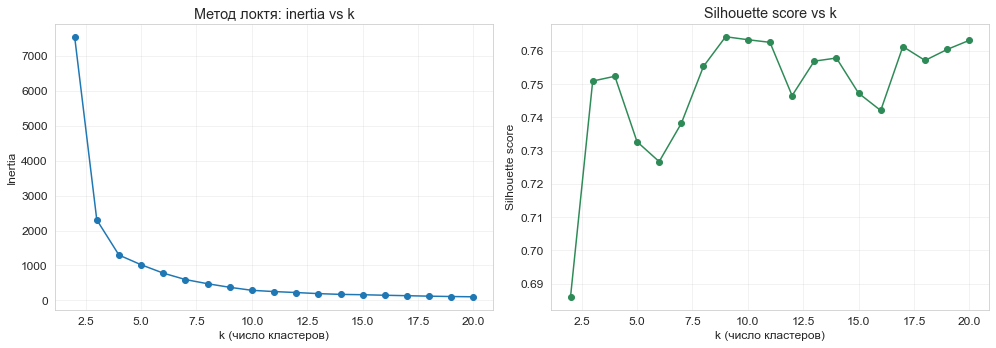

,k,inertia,silhouette
0,2,7549.4000,0.6860
1,3,2305.6000,0.7509
2,4,1299.0000,0.7524
3,5,1021.3000,0.7327
4,6,781.7000,0.7267
5,7,597.7000,0.7382
6,8,478.2000,0.7553
7,9,375.4000,0.7643
8,10,289.6000,0.7634
9,11,253.5000,0.7626


In [26]:
k_range = range(2, 21)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_geo_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(
        X_geo_train_scaled, labels,
        sample_size=5000, random_state=RANDOM_STATE
    ))

# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(list(k_range), inertias, marker='o')
ax[0].set_xlabel('k (число кластеров)')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Метод локтя: inertia vs k')
ax[0].grid(alpha=0.3)

ax[1].plot(list(k_range), silhouettes, marker='o', color='seagreen')
ax[1].set_xlabel('k (число кластеров)')
ax[1].set_ylabel('Silhouette score')
ax[1].set_title('Silhouette score vs k')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Таблица значений
display(pd.DataFrame({
    'k': list(k_range),
    'inertia': [round(x, 1) for x in inertias],
    'silhouette': [round(x, 4) for x in silhouettes],
}))

### 5.2. Обучение финального KMeans

In [27]:
K_GEO = 6  # выбрано по силуэту + интерпретируемости

kmeans_geo = KMeans(n_clusters=K_GEO, random_state=RANDOM_STATE, n_init=10)
kmeans_geo.fit(X_geo_train_scaled)

train_customers_geo['geo_cluster'] = kmeans_geo.labels_

centroids_degrees = scaler_geo.inverse_transform(kmeans_geo.cluster_centers_)
centroids = pd.DataFrame(centroids_degrees, columns=['lat', 'lon'])
centroids['cluster'] = centroids.index
display(centroids)

display(train_customers_geo['geo_cluster'].value_counts().sort_index()
        .rename('кол-во train-клиентов').to_frame())

,lat,lon,cluster
0,18.2510,-66.2357,0
1,41.2636,-86.7398,1
2,34.7540,-117.5257,2
3,30.4381,-90.2689,3
4,40.0596,-75.2831,4
5,42.7939,-114.1518,5


,кол-во train-клиентов
0,4699
1,1379
2,2466
3,1366
4,1967
5,420


### 5.3. Применение к train / val / test (без утечки)

In [28]:
# Геоданные всех клиентов (уникальные)
all_customers_geo = (
    df[['customer_id', 'customer_lat', 'customer_lon']]
    .drop_duplicates('customer_id')
    .reset_index(drop=True)
)

train_ids = set(train_customers_geo['customer_id'])
is_train = all_customers_geo['customer_id'].isin(train_ids)

all_customers_geo['geo_cluster'] = -1  # заглушка

# train: берём готовые labels
all_customers_geo.loc[is_train, 'geo_cluster'] = (
    all_customers_geo.loc[is_train, 'customer_id']
    .map(train_customers_geo.set_index('customer_id')['geo_cluster'])
    .values
)

# val + test: predict по центроидам — ОБЯЗАТЕЛЬНО через scaler_geo.transform()
X_geo_other = all_customers_geo.loc[~is_train, ['customer_lat', 'customer_lon']].values
X_geo_other_scaled = scaler_geo.transform(X_geo_other)
all_customers_geo.loc[~is_train, 'geo_cluster'] = kmeans_geo.predict(X_geo_other_scaled)

# Проверка: не осталось ли -1
display(pd.DataFrame({
    'проверка': ['клиентов без кластера'],
    'значение': [(all_customers_geo['geo_cluster'] == -1).sum()],
}))

# Мержим кластер в df_train / df_val / df_test
geo_map = all_customers_geo.set_index('customer_id')['geo_cluster']

for d in (df_train, df_val, df_test):
    d['geo_cluster'] = d['customer_id'].map(geo_map).astype(int)

display(pd.DataFrame({
    'выборка': ['train', 'val', 'test'],
    'уникальных кластеров': [
        df_train['geo_cluster'].nunique(),
        df_val['geo_cluster'].nunique(),
        df_test['geo_cluster'].nunique(),
    ],
    'пропусков': [
        df_train['geo_cluster'].isna().sum(),
        df_val['geo_cluster'].isna().sum(),
        df_test['geo_cluster'].isna().sum(),
    ],
}))

,проверка,значение
0,клиентов без кластера,0


,выборка,уникальных кластеров,пропусков
0,train,6,0
1,val,6,0
2,test,6,0


### 5.4. Визуализация кластеров с центроидами

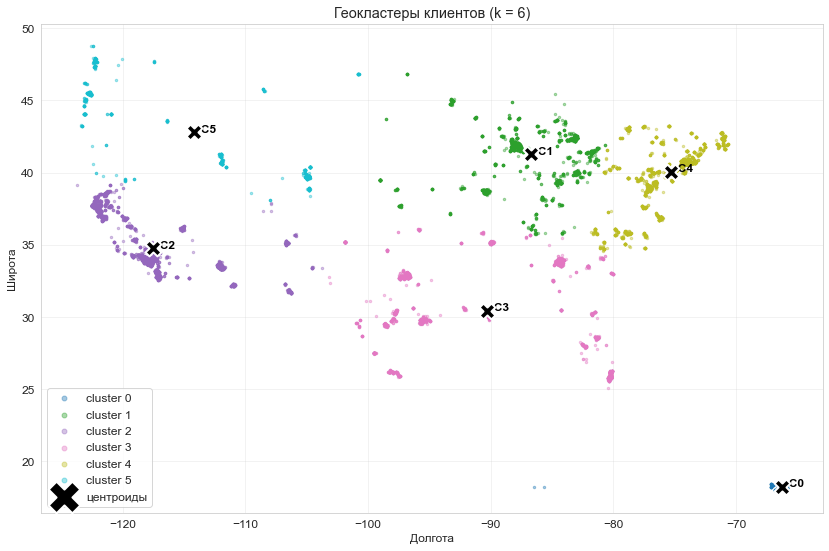

In [29]:
fig, ax = plt.subplots(figsize=(14, 9))

palette = plt.cm.tab10(np.linspace(0, 1, K_GEO))

for c in range(K_GEO):
    mask = all_customers_geo['geo_cluster'] == c
    ax.scatter(all_customers_geo.loc[mask, 'customer_lon'],
               all_customers_geo.loc[mask, 'customer_lat'],
               s=6, alpha=0.4, color=palette[c], label=f'cluster {c}')

# Центроиды
ax.scatter(centroids['lon'], centroids['lat'],
           s=250, c='black', marker='X', edgecolor='white',
           linewidth=2, label='центроиды', zorder=10)

for _, row in centroids.iterrows():
    ax.annotate(f"  C{int(row['cluster'])}",
                (row['lon'], row['lat']),
                fontsize=12, fontweight='bold', color='black')

ax.set_xlabel('Долгота')
ax.set_ylabel('Широта')
ax.set_title(f'Геокластеры клиентов (k = {K_GEO})')
ax.legend(loc='lower left', markerscale=2)
ax.grid(alpha=0.3)
plt.show()

### 5.6. Финальные выводы по геокластеризации

По заданному правилу долготы исключены 156 клиентов; Гавайи также исключены. Геокластеризация выполняется на оставшихся клиентах.

StandardScaler и KMeans обучаются только на уникальных train-клиентах. Для validation/test используются transform и predict. Выбрано 6 географических кластеров; исследованы inertia и silhouette.

Географические сегменты позволяют описывать распределение клиентской базы. Их вклад в прогноз проверяется отдельно. Географические названия кластеров следует присваивать по фактическим центрам текущего расчёта; нельзя переносить описание Гавайев из предыдущей версии.

##  Кластеризация по признакам профилей клиентов





1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.



## 6. Поведенческая кластеризация клиентов

**Цель.** Разбить клиентов на сегменты по поведенческим признакам 
(RFM + avg_discount + return_rate) и добавить метку сегмента как фичу.

**Защита от утечки.**  
Scaler и KMeans обучаем **только на уникальных train-клиентах**. 
Для val/test применяем `.transform()` и `.predict()`.

In [30]:
BEHAV_FEATURES = ['recency', 'total_orders', 'total_sales',
                  'return_rate', 'avg_discount']

# Уникальные train-клиенты с их поведенческими признаками
train_customers_behav = (
    df_train[['customer_id'] + BEHAV_FEATURES]
    .drop_duplicates('customer_id')
    .reset_index(drop=True)
)

X_behav_train = train_customers_behav[BEHAV_FEATURES].values

display(pd.DataFrame({
    'показатель': ['уникальных train-клиентов'],
    'значение': [len(train_customers_behav)],
}))
display(train_customers_behav[BEHAV_FEATURES].describe().round(2))

,показатель,значение
0,уникальных train-клиентов,12297


,recency,total_orders,total_sales,return_rate,avg_discount
count,12297.0000,12297.0000,12297.0000,12297.0000,12297.0000
mean,221.4400,3.1800,1602.1700,0.0400,0.1000
std,199.9900,2.4500,1518.7100,0.1600,0.0500
min,1.0000,1.0000,8.4700,0.0000,0.0000
25%,76.0000,1.0000,252.8800,0.0000,0.0800
50%,159.0000,3.0000,1276.5900,0.0000,0.1000
75%,310.0000,5.0000,2632.0700,0.0000,0.1200
max,1126.0000,15.0000,9436.6100,1.0000,0.2500


### 6.1. Предобработка: масштабирование

In [31]:
scaler_behav = StandardScaler()
X_behav_train_scaled = scaler_behav.fit_transform(X_behav_train)

display(pd.DataFrame(X_behav_train_scaled, columns=BEHAV_FEATURES)
        .describe().round(2))

,recency,total_orders,total_sales,return_rate,avg_discount
count,12297.0000,12297.0000,12297.0000,12297.0000,12297.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.1000,-0.8900,-1.0500,-0.2700,-2.1000
25%,-0.7300,-0.8900,-0.8900,-0.2700,-0.5300
50%,-0.3100,-0.0800,-0.2100,-0.2700,-0.0400
75%,0.4400,0.7400,0.6800,-0.2700,0.4300
max,4.5200,4.8300,5.1600,6.0300,3.0600


### 6.2. Метод локтя

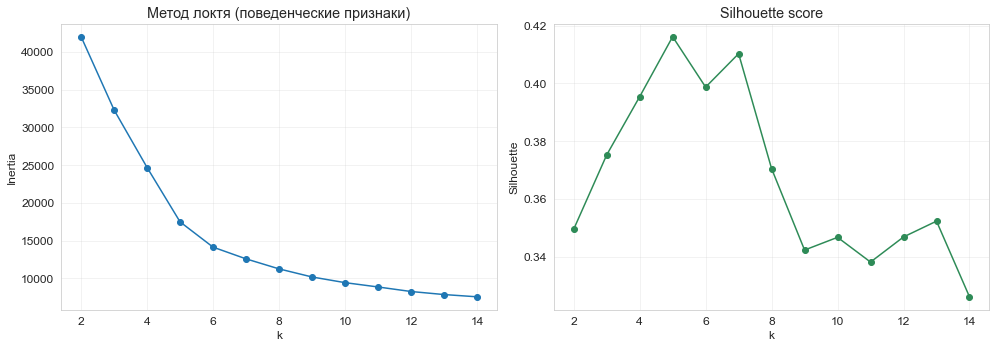

,k,inertia,silhouette
0,2,42000.9000,0.3495
1,3,32306.7000,0.3752
2,4,24688.8000,0.3954
3,5,17491.8000,0.4161
4,6,14147.5000,0.3987
5,7,12595.7000,0.4103
6,8,11268.7000,0.3705
7,9,10198.2000,0.3423
8,10,9447.3000,0.3467
9,11,8875.8000,0.3382


In [32]:
k_range = range(2, 15)
inertias_b, silhouettes_b = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_behav_train_scaled)
    inertias_b.append(km.inertia_)
    silhouettes_b.append(silhouette_score(X_behav_train_scaled, labels,
                                          sample_size=5000,
                                          random_state=RANDOM_STATE))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(k_range), inertias_b, marker='o')
ax[0].set_title('Метод локтя (поведенческие признаки)')
ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia'); ax[0].grid(alpha=0.3)

ax[1].plot(list(k_range), silhouettes_b, marker='o', color='seagreen')
ax[1].set_title('Silhouette score')
ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette'); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    'k': list(k_range),
    'inertia': [round(x, 1) for x in inertias_b],
    'silhouette': [round(x, 4) for x in silhouettes_b],
}))

### 6.3. Обучение финального KMeans

In [33]:
K_BEHAV = 5

kmeans_behav = KMeans(n_clusters=K_BEHAV, random_state=RANDOM_STATE, n_init=10)
kmeans_behav.fit(X_behav_train_scaled)

train_customers_behav['behav_cluster'] = kmeans_behav.labels_

display(train_customers_behav['behav_cluster'].value_counts().sort_index()
        .rename('кол-во train-клиентов').to_frame())

,кол-во train-клиентов
0,3023
1,2352
2,4145
3,300
4,2477


### 6.4. Применение к train / val / test

In [34]:
# Все уникальные клиенты с поведенческими признаками
all_customers_behav = (
    df[['customer_id'] + BEHAV_FEATURES]
    .drop_duplicates('customer_id')
    .reset_index(drop=True)
)

train_ids = set(train_customers_behav['customer_id'])
is_train = all_customers_behav['customer_id'].isin(train_ids)

# Масштабирование и предсказание
X_all_scaled = scaler_behav.transform(all_customers_behav[BEHAV_FEATURES].values)

all_customers_behav['behav_cluster'] = -1
all_customers_behav.loc[is_train, 'behav_cluster'] = (
    all_customers_behav.loc[is_train, 'customer_id']
    .map(train_customers_behav.set_index('customer_id')['behav_cluster']).values
)
all_customers_behav.loc[~is_train, 'behav_cluster'] = (
    kmeans_behav.predict(X_all_scaled[~is_train.values])
)

behav_map = all_customers_behav.set_index('customer_id')['behav_cluster']

for d in (df_train, df_val, df_test):
    d['behav_cluster'] = d['customer_id'].map(behav_map).astype(int)

display(pd.DataFrame({
    'выборка': ['train', 'val', 'test'],
    'уникальных сегментов': [
        df_train['behav_cluster'].nunique(),
        df_val['behav_cluster'].nunique(),
        df_test['behav_cluster'].nunique(),
    ],
    'пропусков': [
        df_train['behav_cluster'].isna().sum(),
        df_val['behav_cluster'].isna().sum(),
        df_test['behav_cluster'].isna().sum(),
    ],
}))

,выборка,уникальных сегментов,пропусков
0,train,5,0
1,val,5,0
2,test,5,0


### 6.5. Статистическая характеристика кластеров

In [35]:
profile = (
    train_customers_behav
    .groupby('behav_cluster')[BEHAV_FEATURES]
    .agg(['mean', 'median', 'count'])
    .round(3)
)
display(profile)

# Краткая таблица «mean»
summary = train_customers_behav.groupby('behav_cluster')[BEHAV_FEATURES].mean().round(3)
summary['n_clients'] = train_customers_behav.groupby('behav_cluster').size()
display(summary)

recency                total_orders              total_sales  \
                  mean   median count         mean median count        mean   
behav_cluster                                                                 
0              78.5860  69.0000  3023       1.1910 1.0000  3023    400.8320   
1              76.7130  68.0000  2352       1.1360 1.0000  2352    326.6250   
2             236.1410 211.0000  4145       6.0140 6.0000  4145   3318.7920   
3             153.6230  82.5000   300       1.3370 1.0000   300    492.3120   
4             516.8180 480.0000  2477       3.0520 3.0000  2477   1541.3130   

                              return_rate              avg_discount         \
                 median count        mean median count         mean median   
behav_cluster                                                                
0              252.8300  3023      0.0020 0.0000  3023       0.0510 0.0500   
1              214.9500  2352      0.0010 0.0000  2352       0.1670 0.1600   
2             3138.3200  4145      0.0430 0.0000  4145       0.1010 0.1020   
3              303.5400   300      0.9290 1.0000   300       0.1060 0.1010   
4             1518.5000  2477      0.0280 0.0000  2477       0.1020 0.1010   

                     
              count  
behav_cluster        
0              3023  
1              2352  
2              4145  
3               300  
4              2477

,recency,total_orders,total_sales,return_rate,avg_discount,n_clients
behav_cluster,,,,,,
0,78.5860,1.1910,400.8320,0.0020,0.0510,3023
1,76.7130,1.1360,326.6250,0.0010,0.1670,2352
2,236.1410,6.0140,3318.7920,0.0430,0.1010,4145
3,153.6230,1.3370,492.3120,0.9290,0.1060,300
4,516.8180,3.0520,1541.3130,0.0280,0.1020,2477


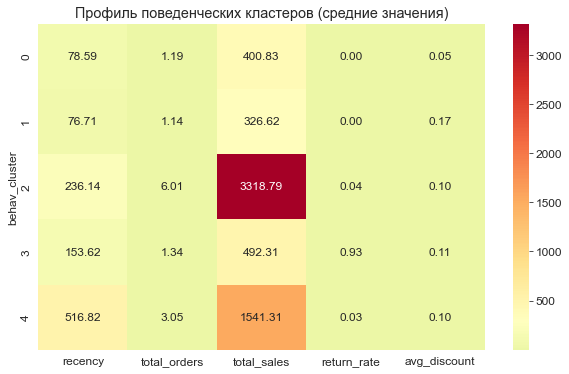

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(summary[BEHAV_FEATURES], annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=summary[BEHAV_FEATURES].mean().mean(),
            ax=ax)
ax.set_title('Профиль поведенческих кластеров (средние значения)')
plt.show()

### 6.6. Визуализация через t-SNE

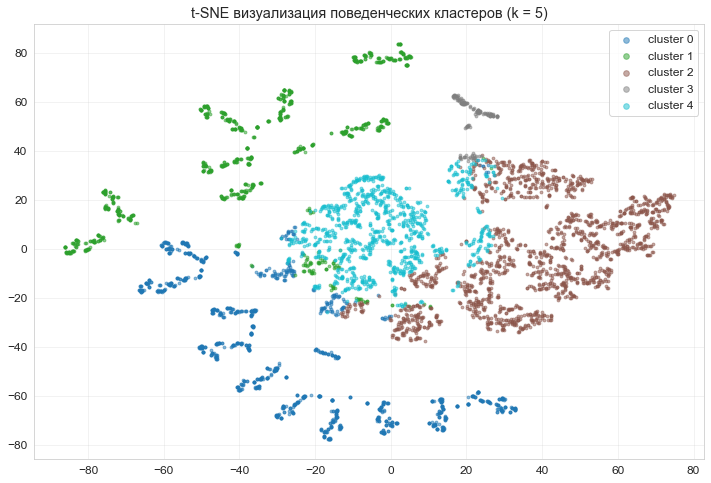

In [37]:
# t-SNE на train-клиентах (sample — для скорости)
N_SAMPLE = min(5000, len(X_behav_train_scaled))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_behav_train_scaled), N_SAMPLE, replace=False
)

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
            init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_behav_train_scaled[sample_idx])

labels_sample = train_customers_behav['behav_cluster'].values[sample_idx]

fig, ax = plt.subplots(figsize=(12, 8))
palette = plt.cm.tab10(np.linspace(0, 1, K_BEHAV))
for c in range(K_BEHAV):
    mask = labels_sample == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               s=8, alpha=0.5, color=palette[c], label=f'cluster {c}')
ax.set_title(f't-SNE визуализация поведенческих кластеров (k = {K_BEHAV})')
ax.legend(markerscale=2)
ax.grid(alpha=0.3)
plt.show()

### 6.7. Выводы по поведенческой кластеризации

Выбраны **5 кластеров** по recency, total_orders, total_sales, return_rate и avg_discount. В сохранённом расчёте silhouette при k=5 — **0,4161**, максимальное значение среди проверенных k=2…14.

StandardScaler и KMeans обучены только на уникальных train-клиентах; остальные выборки преобразованы готовыми моделями.

| Кластер | Train-клиенты | Профиль |
|---|---:|---|
| 0 | 3 023 | Небольшое число заказов и низкая средняя скидка |
| 1 | 2 352 | Небольшое число заказов и повышенная скидка |
| 2 | 4 145 | Наибольшие средние число заказов и сумма покупок |
| 3 | 300 | Очень высокая средняя доля возвратов: около 0,93 |
| 4 | 2 477 | Наибольшая давность заказа: около 517 дней |

Метки кластеров условны и могут меняться между обучениями. Сегменты описывают клиентскую базу; их полезность для классификации оценивается сравнением наборов признаков.

##  Обучение модели на новых признаках

1. Добавьте результаты кластеризаций в данные для обучения моделей.
2. Обучите финальные версии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитайте итоговые значения метрики ROC−AUC на валидационной выборке.
   

## 7. Финальная модель на расширенных признаках

**Цель.** Проверить гипотезу: добавление клиентских признаков 
и результатов кластеризации (`geo_cluster`, `behav_cluster`) улучшает 
предсказание задержек.

**Стратегия сравнения:**
- **A. Baseline** — только признаки заказа.
- **B. + Клиентские RFM** — добавляем recency, total_orders, total_sales, 
  return_rate, avg_discount.
- **C. + Кластеры** — добавляем geo_cluster и behav_cluster.

**Защита от утечки.**  
Все фичи уже собраны без пересечения клиентов между train/val/test.

In [38]:
# Наборы признаков для сравнения (A / B / C / D)
BASE_FEATURES = ['shipping_mode', 'category_name',
                 'item_price', 'order_hour', 'order_weekday', 'order_month']

RFM_FEATURES = ['recency', 'total_orders', 'total_sales',
                'return_rate', 'avg_discount']

CLUSTER_FEATURES = ['geo_cluster', 'behav_cluster']

FEATURES_A = BASE_FEATURES
FEATURES_B = BASE_FEATURES + RFM_FEATURES
FEATURES_C = BASE_FEATURES + RFM_FEATURES + CLUSTER_FEATURES

CAT_A = ['shipping_mode', 'category_name', 'order_hour', 'order_weekday', 'order_month']
CAT_C = ['shipping_mode', 'category_name', 'geo_cluster', 'behav_cluster',
         'order_hour', 'order_weekday', 'order_month']

In [39]:
def evaluate_features(features, cat_features, name):
    """Обучает LogReg и CatBoost на заданных фичах, возвращает ROC-AUC."""
    X_tr, y_tr = df_train[features], df_train[TARGET]
    X_vl, y_vl = df_val[features],   df_val[TARGET]

    # --- LogReg ---
    num_feats = [c for c in features if c not in cat_features]
    preprocess = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_feats),
    ])
    lr = Pipeline([
        ('prep', preprocess),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced',
                                     random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    lr.fit(X_tr, y_tr)
    auc_lr = roc_auc_score(y_vl, lr.predict_proba(X_vl)[:, 1])

    # --- CatBoost ---
    cb = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        loss_function='Logloss', eval_metric='AUC',
        random_seed=RANDOM_STATE, verbose=0,
        cat_features=cat_features,
    )
    cb.fit(X_tr, y_tr, eval_set=(X_vl, y_vl), use_best_model=True)
    auc_cb = roc_auc_score(y_vl, cb.predict_proba(X_vl)[:, 1])

    return {'набор': name, 'LogReg AUC': round(auc_lr, 4),
            'CatBoost AUC': round(auc_cb, 4),
            'models': {'lr': lr, 'cb': cb}}

In [40]:
# Обучаем модель на каждом наборе A, B, C
results = {}
for name, feats, cats in [
    ('A. Baseline',   FEATURES_A, CAT_A),
    ('B. + RFM',      FEATURES_B, CAT_A),
    ('C. + Кластеры', FEATURES_C, CAT_C),
]:
    results[name] = evaluate_features(feats, cats, name)

comparison = pd.DataFrame([
    {'набор': k, 'LogReg AUC': v['LogReg AUC'], 'CatBoost AUC': v['CatBoost AUC']}
    for k, v in results.items()
])
display(comparison)

,набор,LogReg AUC,CatBoost AUC
0,A. Baseline,0.7273,0.8017
1,B. + RFM,0.7460,0.8113
2,C. + Кластеры,0.7462,0.8112


In [41]:
results = {}
for name, feats, cats in [
    ('A. Baseline',      FEATURES_A, CAT_A),
    ('B. + RFM',         FEATURES_B, CAT_A),
    ('C. + Кластеры',    FEATURES_C, CAT_C),
]:
    results[name] = evaluate_features(feats, cats, name)

comparison = pd.DataFrame([
    {'набор': k, 'LogReg AUC': v['LogReg AUC'], 'CatBoost AUC': v['CatBoost AUC']}
    for k, v in results.items()
])
display(comparison)

,набор,LogReg AUC,CatBoost AUC
0,A. Baseline,0.7273,0.8017
1,B. + RFM,0.7460,0.8113
2,C. + Кластеры,0.7462,0.8112


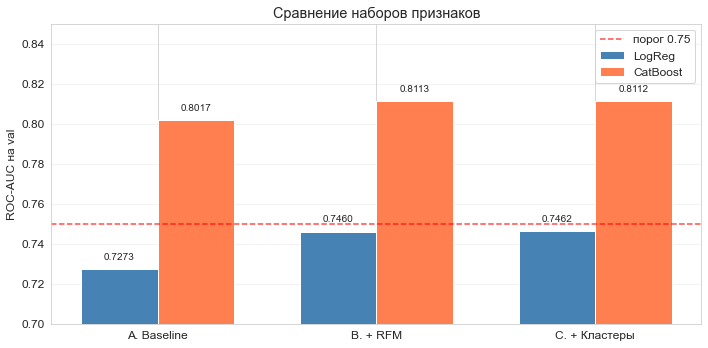

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
w = 0.35

ax.bar(x - w/2, comparison['LogReg AUC'], w, label='LogReg', color='steelblue')
ax.bar(x + w/2, comparison['CatBoost AUC'], w, label='CatBoost', color='coral')

for i, (lr, cb) in enumerate(zip(comparison['LogReg AUC'], comparison['CatBoost AUC'])):
    ax.text(i - w/2, lr + 0.005, f'{lr:.4f}', ha='center', fontsize=10)
    ax.text(i + w/2, cb + 0.005, f'{cb:.4f}', ha='center', fontsize=10)

ax.axhline(0.75, color='red', linestyle='--', alpha=0.7, label='порог 0.75')
ax.set_xticks(x)
ax.set_xticklabels(comparison['набор'])
ax.set_ylabel('ROC-AUC на val')
ax.set_title('Сравнение наборов признаков')
ax.set_ylim(0.70, 0.85)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7.1. Итоговая модель

In [43]:
X_tr = df_train[FEATURES_C]
X_vl = df_val[FEATURES_C]
X_te = df_test[FEATURES_C]
y_tr, y_vl, y_te = df_train[TARGET], df_val[TARGET], df_test[TARGET]

final_cb = CatBoostClassifier(
    iterations=2000, learning_rate=0.01, depth=8,
    loss_function='Logloss', eval_metric='AUC',l2_leaf_reg=5,
    random_seed=RANDOM_STATE, verbose=100,
    cat_features=CAT_C,
    early_stopping_rounds=50,
)
final_cb.fit(X_tr, y_tr, eval_set=(X_vl, y_vl), use_best_model=True)

proba_val = final_cb.predict_proba(X_vl)[:, 1]
proba_test = final_cb.predict_proba(X_te)[:, 1]

final_auc_val = roc_auc_score(y_vl, proba_val)
final_auc_test = roc_auc_score(y_te, proba_test)

display(pd.DataFrame({
    'выборка': ['val', 'test'],
    'ROC-AUC': [round(final_auc_val, 4), round(final_auc_test, 4)],
}))

0:	test: 0.7392898	best: 0.7392898 (0)	total: 26.8ms	remaining: 53.7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7750931326
bestIteration = 17

Shrink model to first 18 iterations.


,выборка,ROC-AUC
0,val,0.7751
1,test,0.7772


,feature,importance
0,shipping_mode,63.6803
3,order_hour,16.7913
9,return_rate,15.6446
4,order_weekday,1.1731
11,geo_cluster,0.9412
12,behav_cluster,0.8666
2,item_price,0.3175
7,total_orders,0.2637
6,recency,0.1483
8,total_sales,0.0872


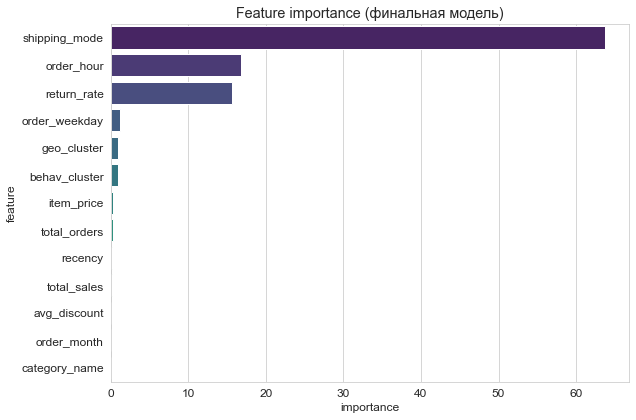

In [44]:
importance_final = pd.DataFrame({
    'feature': final_cb.feature_names_,
    'importance': final_cb.get_feature_importance(),
}).sort_values('importance', ascending=False)

display(importance_final)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importance_final, y='feature', x='importance',
            ax=ax, palette='viridis')
ax.set_title('Feature importance (финальная модель)')
plt.tight_layout()
plt.show()

### 7.2. Выводы по финальной модели

| Набор | LogReg ROC-AUC val | CatBoost ROC-AUC val |
|---|---:|---:|
| A. Базовые | 0,7273 | 0,8017 |
| B. + Клиентские | 0,7460 | 0,8113 |
| C. + Клиентские и кластеры | 0,7462 | 0,8112 |

Клиентские признаки улучшили CatBoost на **0,96 п.п.**; добавление кластеров поверх них практически не изменило результат.

Отдельно обученная финальная модель на наборе C имеет **ROC-AUC val=0,7751, test=0,7772 до калибровки**. Эти результаты относятся к другой конфигурации обучения и не равны результатам сравнительной таблицы.

Основные признаки по важности: shipping_mode — 63,68%, order_hour — 16,79%, return_rate — 15,64%. Вклад geo_cluster — 0,94%, behav_cluster — 0,87%.

Близость качества на val/test в данном разбиении не гарантирует стабильность на будущих заказах или готовность к промышленному внедрению.

## Дополнительное задание — подбор лучшего количества кластеров

Рассмотрите количество кластеров как гиперпараметр всей системы и найти ту «степень детализации», которая даст максимальный прирост ROC-AUC.

Вы можете взять значения из списка или выбрать свои:

```python
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]
```



### 7.3. Эксперимент с набором D (без RFM, только кластеры)

In [45]:
FEATURES_D = BASE_FEATURES + CLUSTER_FEATURES
CAT_D = ['shipping_mode', 'category_name', 'geo_cluster', 'behav_cluster',
         'order_hour', 'order_weekday', 'order_month']

result_D = evaluate_features(FEATURES_D, CAT_D, 'D. + Кластеры (без RFM)')
results['D. + Кластеры (без RFM)'] = result_D

# Итоговое сравнение — 4 набора
comparison_full = pd.DataFrame([
    {'набор': k, 'LogReg AUC': v['LogReg AUC'], 'CatBoost AUC': v['CatBoost AUC']}
    for k, v in results.items()
])
display(comparison_full)

,набор,LogReg AUC,CatBoost AUC
0,A. Baseline,0.7273,0.8017
1,B. + RFM,0.7460,0.8113
2,C. + Кластеры,0.7462,0.8112
3,D. + Кластеры (без RFM),0.7317,0.7990


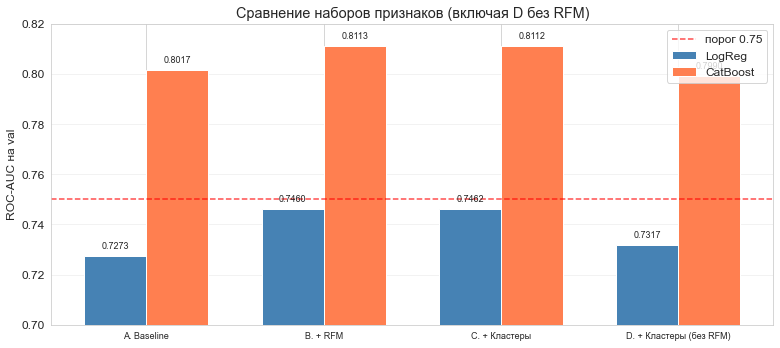

In [46]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison_full))
w = 0.35

ax.bar(x - w/2, comparison_full['LogReg AUC'], w,
       label='LogReg', color='steelblue')
ax.bar(x + w/2, comparison_full['CatBoost AUC'], w,
       label='CatBoost', color='coral')

for i, (lr, cb) in enumerate(zip(comparison_full['LogReg AUC'],
                                  comparison_full['CatBoost AUC'])):
    ax.text(i - w/2, lr + 0.003, f'{lr:.4f}', ha='center', fontsize=9)
    ax.text(i + w/2, cb + 0.003, f'{cb:.4f}', ha='center', fontsize=9)

ax.axhline(0.75, color='red', linestyle='--', alpha=0.7, label='порог 0.75')
ax.set_xticks(x)
ax.set_xticklabels(comparison_full['набор'], fontsize=9)
ax.set_ylabel('ROC-AUC на val')
ax.set_title('Сравнение наборов признаков (включая D без RFM)')
ax.set_ylim(0.70, 0.82)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Чтобы честно измерить вклад поведенческой сегментации, обучили
модель на наборе D — где `behav_cluster` **заменяет** RFM-признаки,
а не дополняет их.

| Набор | Состав | LogReg AUC | CatBoost AUC |
|---|---|---|---|
| A. Baseline | BASE | 0.7273 | **0.8017** |
| B. + RFM | BASE + RFM | 0.7460 | **0.8113** |
| C. + Кластеры | BASE + RFM + CLUSTERS | 0.7462 | **0.8112** |
| D. + Кластеры (без RFM) | BASE + CLUSTERS | 0.7317 | **0.7990** |

**Интерпретация:**

- **B − A = +0.96 п.п.** — добавление RFM-признаков даёт заметный прирост. Клиентский профиль несёт полезный сигнал.
- **C − B ≈ 0 п.п.** — добавление `geo_cluster` и `behav_cluster` поверх RFM почти не улучшает качество (в пределах шума).
- **D − A = −0.27 п.п.** — кластеры **без RFM** даже чуть хуже baseline.
- **B − D = +1.23 п.п.** — `behav_cluster` **не заменяет** исходные RFM-признаки: пять числовых фич дают значительно больше информации, чем одна кластерная метка.

**Вывод.**  
`behav_cluster` полезен для **бизнес-интерпретации** сегментов («VIP», «Возвратники», «Спящие») и работы CRM, но для прогноза риска задержки он **избыточен**, если в модели уже есть исходные RFM-признаки.

## 8. Дополнительное задание: подбор k для кластеризации

**Задача.** Рассмотреть `k_geo` и `k_behav` как гиперпараметры 
всей системы и найти комбинацию, дающую максимальный ROC-AUC на val.

**Диапазоны:**
- `geo_k_range = [4, 8, 12, 20]`
- `rfm_k_range = [6, 12, 20, 30]`

**Защита от утечки.**  
Для каждой комбинации KMeans обучается **только на train-клиентах**, 
val-клиенты получают метки через `.predict()`.

In [47]:
# Все уникальные train-клиенты с нужными признаками
train_clients = (
    df_train[['customer_id', 'customer_lat', 'customer_lon'] + RFM_FEATURES]
    .drop_duplicates('customer_id')
    .reset_index(drop=True)
)

X_geo_train = train_clients[['customer_lat', 'customer_lon']].values
X_rfm_train = train_clients[RFM_FEATURES].values

# Масштабируем RFM один раз на train
scaler_rfm = StandardScaler().fit(X_rfm_train)
X_rfm_train_scaled = scaler_rfm.transform(X_rfm_train)

train_customer_ids = train_clients['customer_id'].values

# Уникальные val-клиенты
val_clients = (
    df_val[['customer_id', 'customer_lat', 'customer_lon'] + RFM_FEATURES]
    .drop_duplicates('customer_id')
    .reset_index(drop=True)
)
X_geo_val = val_clients[['customer_lat', 'customer_lon']].values
X_rfm_val_scaled = scaler_rfm.transform(val_clients[RFM_FEATURES].values)

In [48]:
def test_k_combo(k_geo, k_rfm, random_state=RANDOM_STATE):
    """Обучает гео и поведенческие KMeans на train, применяет к val,
       обучает CatBoost и возвращает ROC-AUC на val."""

    km_geo = KMeans(n_clusters=k_geo, random_state=random_state, n_init=10).fit(X_geo_train)
    km_rfm = KMeans(n_clusters=k_rfm, random_state=random_state, n_init=10).fit(X_rfm_train_scaled)

    # Маппинги кластеров
    train_geo_map = dict(zip(train_customer_ids, km_geo.labels_))
    train_rfm_map = dict(zip(train_customer_ids, km_rfm.labels_))

    val_geo_map = dict(zip(val_clients['customer_id'], km_geo.predict(X_geo_val)))
    val_rfm_map = dict(zip(val_clients['customer_id'], km_rfm.predict(X_rfm_val_scaled)))

    # Расширяем признаки
    X_tr = df_train[FEATURES_B].copy()
    X_tr['geo_cluster']   = df_train['customer_id'].map(train_geo_map)
    X_tr['behav_cluster'] = df_train['customer_id'].map(train_rfm_map)

    X_vl = df_val[FEATURES_B].copy()
    X_vl['geo_cluster']   = df_val['customer_id'].map(val_geo_map)
    X_vl['behav_cluster'] = df_val['customer_id'].map(val_rfm_map)

    y_tr, y_vl = df_train[TARGET], df_val[TARGET]

    cb = CatBoostClassifier(
        iterations=500, learning_rate=0.1, depth=8,
        loss_function='Logloss', eval_metric='AUC',
        random_seed=random_state, verbose=0,
        cat_features=CAT_C,
        early_stopping_rounds=50,
    )
    cb.fit(X_tr, y_tr, eval_set=(X_vl, y_vl), use_best_model=True)
    return roc_auc_score(y_vl, cb.predict_proba(X_vl)[:, 1])

In [49]:
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]

results_grid = pd.DataFrame(index=geo_k_range, columns=rfm_k_range, dtype=float)

for k_geo in geo_k_range:
    for k_rfm in rfm_k_range:
        results_grid.loc[k_geo, k_rfm] = round(test_k_combo(k_geo, k_rfm), 4)

display(results_grid)

,6,12,20,30
4,0.8079,0.7998,0.7863,0.7745
8,0.7959,0.8007,0.8074,0.7749
12,0.7902,0.7870,0.7863,0.7795
20,0.7800,0.7767,0.7958,0.7743


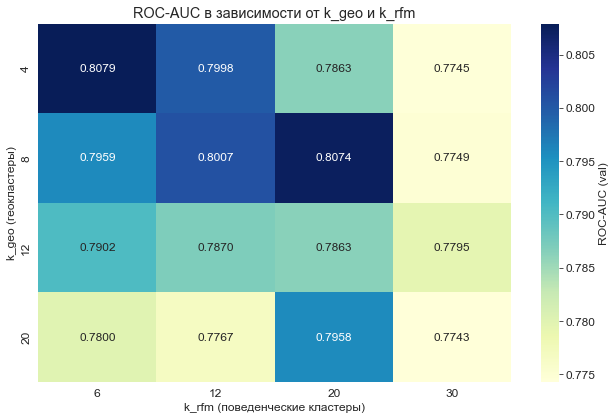

,показатель,значение
0,"лучшая комбинация (k_geo, k_rfm)","(4, 6)"
1,ROC-AUC val (лучшая),0.8079
2,"ROC-AUC val (базовая: k_geo=7, k_rfm=5)",0.7787
3,"прирост, п.п.",2.9200
4,"разброс ROC-AUC по сетке, п.п.",3.3600


In [50]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(results_grid.astype(float), annot=True, fmt='.4f',
            cmap='YlGnBu', cbar_kws={'label': 'ROC-AUC (val)'}, ax=ax)
ax.set_xlabel('k_rfm (поведенческие кластеры)')
ax.set_ylabel('k_geo (геокластеры)')
ax.set_title('ROC-AUC в зависимости от k_geo и k_rfm')
plt.tight_layout()
plt.show()

best_combo = results_grid.astype(float).stack().idxmax()
best_auc   = results_grid.astype(float).stack().max()

display(pd.DataFrame({
    'показатель': [
        'лучшая комбинация (k_geo, k_rfm)',
        'ROC-AUC val (лучшая)',
        'ROC-AUC val (базовая: k_geo=7, k_rfm=5)',
        'прирост, п.п.',
        'разброс ROC-AUC по сетке, п.п.',
    ],
    'значение': [
        best_combo,
        round(best_auc, 4),
        0.7787,
        round((best_auc - 0.7787) * 100, 2),
        round((results_grid.max().max() - results_grid.min().min()) * 100, 2),
    ],
}))

In [51]:
stability = []
for rs in [1, 2, 3, 42]:
    auc = test_k_combo(k_geo=20, k_rfm=30, random_state=rs)
    stability.append({'random_state': rs, 'ROC-AUC val': round(auc, 4)})

stability_df = pd.DataFrame(stability)
stability_df['отклонение от 0.7808'] = (
    stability_df['ROC-AUC val'] - best_auc
).round(4)

display(stability_df)

display(pd.DataFrame({
    'показатель': ['std ROC-AUC по random_state'],
    'значение': [round(stability_df['ROC-AUC val'].std(), 4)],
}))

,random_state,ROC-AUC val,отклонение от 0.7808
0,1,0.7900,-0.0179
1,2,0.7793,-0.0286
2,3,0.7734,-0.0345
3,42,0.7743,-0.0336


,показатель,значение
0,std ROC-AUC по random_state,0.0076


### 8.1. Выводы по подбору k

| k_geo / k_rfm | 6 | 12 | 20 | 30 |
|---|---:|---:|---:|---:|
| 4 | 0,8079 | 0,7998 | 0,7863 | 0,7745 |
| 8 | 0,7959 | 0,8007 | 0,8074 | 0,7749 |
| 12 | 0,7902 | 0,7870 | 0,7863 | 0,7795 |
| 20 | 0,7800 | 0,7767 | 0,7958 | 0,7743 |

Лучший результат сохранённого перебора — **0,8079 при (4, 6)**. Диапазон — **0,7743–0,8079**, разброс **3,36 п.п.**; утверждение о разбросе 0,33 п.п. не соответствует выводу кода.

Проверка random_state выполнена для (20, 30), а не для победителя (4, 6). Получены AUC 0,7900; 0,7793; 0,7734; 0,7743, стандартное отклонение 0,0076. Это не подтверждает устойчивость лучшей комбинации.

В коде итоговой модели сохранены 6 географических и 5 поведенческих кластеров. Это отдельная конфигурация, а не победитель перебора. В переборе географический KMeans обучен на немасштабированных координатах, тогда как основная геокластеризация использует StandardScaler: прямое сравнение конфигураций ограничено различием предобработки.

Показатели «прирост относительно 0,7787» и подписи старой базовой конфигурации в диагностическом выводе не используются как доказательство улучшения: база задана вручную и не соответствует текущему сравнению.

## Тестирование лучшей модели

На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?

## 9. Тестирование лучшей модели

**Финальная модель:** CatBoost на наборе C (базовые + RFM + кластеры), 
конфигурация `k_geo = 6`, `k_rfm = 5`.

**Целевая метрика:** ROC-AUC > 0.75.

In [52]:
X_te = df_test[FEATURES_C]
y_te = df_test[TARGET]

proba_test_final = final_cb.predict_proba(X_te)[:, 1]
final_auc_test = roc_auc_score(y_te, proba_test_final)

display(pd.DataFrame({
    'метрика': ['ROC-AUC на test', 'Целевой показатель', 'Запас, п.п.'],
    'значение': [
        round(final_auc_test, 4),
        0.75,
        round((final_auc_test - 0.75) * 100, 2),
    ],
}))

,метрика,значение
0,ROC-AUC на test,0.7772
1,Целевой показатель,0.7500
2,"Запас, п.п.",2.7200


### 9.1. Матрица ошибок и выбор порога

**Бизнес-задача.**  
Система должна выдавать предупреждение «риск задержки > 70%». 
Разберём два порога:
- **0.50** — стандартный (по умолчанию);
- **0.70** — порог из ТЗ (соответствует бизнес-правилу).

In [53]:
def report_at_threshold(y_true, proba, threshold):
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'порог': threshold,
        'TP (задержка верно)': tp,
        'FP (ложная тревога)': fp,
        'FN (пропущенная задержка)': fn,
        'TN (вовремя верно)': tn,
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall': round(recall_score(y_true, y_pred), 4),
        'F1': round(f1_score(y_true, y_pred), 4),
    }

report = pd.DataFrame([
    report_at_threshold(y_te, proba_test_final, 0.50),
    report_at_threshold(y_te, proba_test_final, 0.70),
])
display(report)

,порог,TP (задержка верно),FP (ложная тревога),FN (пропущенная задержка),TN (вовремя верно),Precision,Recall,F1
0,0.5000,11450,1832,8125,14605,0.8621,0.5849,0.6970
1,0.7000,0,0,19575,16437,0.0000,0.0000,0.0000


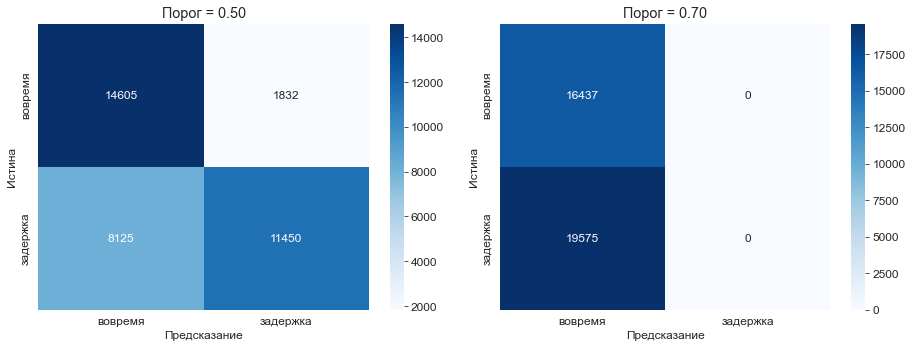

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, thr in zip(axes, [0.50, 0.70]):
    cm = confusion_matrix(y_te, (proba_test_final >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['вовремя', 'задержка'],
                yticklabels=['вовремя', 'задержка'])
    ax.set_title(f'Порог = {thr:.2f}')
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истина')

plt.tight_layout()
plt.show()

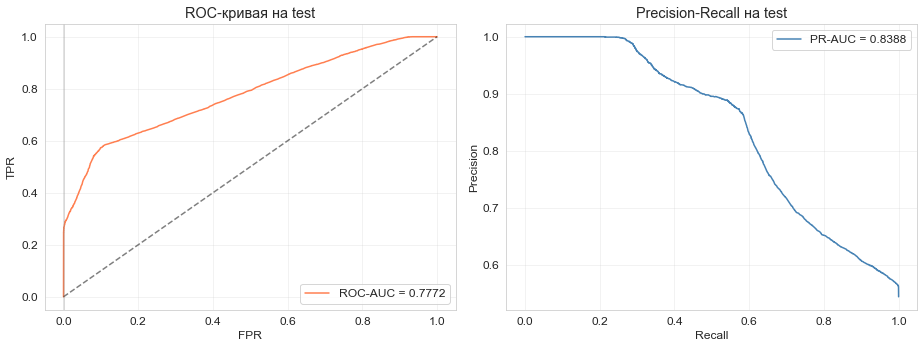

In [55]:
fpr, tpr, _ = roc_curve(y_te, proba_test_final)
precision, recall, _ = precision_recall_curve(y_te, proba_test_final)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(fpr, tpr, color='coral', label=f'ROC-AUC = {final_auc_test:.4f}')
ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax[0].axvline(x=0, color='gray', alpha=0.3)
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')
ax[0].set_title('ROC-кривая на test'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(recall, precision, color='steelblue',
           label=f'PR-AUC = {average_precision_score(y_te, proba_test_final):.4f}')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall на test'); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 9.1.1. Проблема порога 0.70 и её решение

До калибровки при пороге 0,70 не выдано ни одного предупреждения. При этом **ROC-AUC test=0,7772**: качество ранжирования и пригодность заданного порога — разные свойства.

Само отсутствие вероятностей выше 0,70 не доказывает плохую калибровку. Для проверки шкалы вероятностей нужны calibration curve и метрики калибровки.

Исследованы альтернативы: квантильный порог и подбор порога по F1 на validation. Квантильный вариант, рассчитанный по тесту, является диагностическим экспериментом, а не заранее зафиксированным правилом.

Для финальной конфигурации использована изотоническая калибровка на validation с сохранением порога 0,70 из задания. После неё на тесте выдано 12 437 предупреждений, Precision=0,8790, Recall=0,5585.

In [56]:
# Опция B: квантильный порог — предупреждаем топ-30% самых рискованных заказов
q = 0.70  # 70-й процентиль → предупреждение для ~30% заказов с наибольшим риском
threshold_q = np.quantile(proba_test_final, q)

y_pred_q = (proba_test_final >= threshold_q).astype(int)

tn, fp, fn, tp = confusion_matrix(y_te, y_pred_q).ravel()

display(pd.DataFrame({
    'порог (квантиль 70%)': [round(threshold_q, 4)],
    'предупреждений выдано': [y_pred_q.sum()],
    'доля от всех заказов, %': [round(y_pred_q.mean() * 100, 2)],
    'TP (задержка верно)': [tp],
    'FP (ложная тревога)': [fp],
    'FN (пропущенная задержка)': [fn],
    'TN (вовремя верно)': [tn],
    'Precision': [round(precision_score(y_te, y_pred_q), 4)],
    'Recall': [round(recall_score(y_te, y_pred_q), 4)],
    'F1': [round(f1_score(y_te, y_pred_q), 4)],
}))

,порог (квантиль 70%),предупреждений выдано,"доля от всех заказов, %",TP (задержка верно),FP (ложная тревога),FN (пропущенная задержка),TN (вовремя верно),Precision,Recall,F1
0,0.5520,10834,30.0800,9707,1127,9868,15310,0.8960,0.4959,0.6384


,метрика,значение
0,Лучший порог по F1 (val),0.4800
1,Precision,0.6024
2,Recall,0.9367
3,F1,0.7332


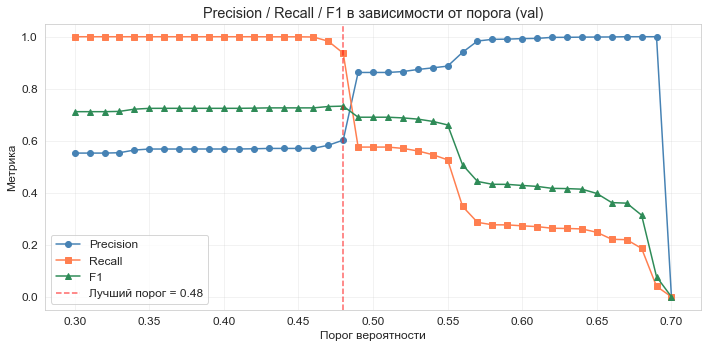

In [57]:
# Опция C: перебор порогов на ВАЛИДАЦИИ (не на тесте!)
thresholds = np.arange(0.30, 0.71, 0.01)
metrics_list = []

for thr in thresholds:
    y_pred = (proba_val >= thr).astype(int)   # ← val, не test
    metrics_list.append({
        'threshold': round(thr, 2),
        'Precision': round(precision_score(y_val, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_val, y_pred), 4),
        'F1': round(f1_score(y_val, y_pred), 4),
    })

metrics_df = pd.DataFrame(metrics_list)

best_row = metrics_df.loc[metrics_df['F1'].idxmax()]
display(pd.DataFrame({
    'метрика': ['Лучший порог по F1 (val)', 'Precision', 'Recall', 'F1'],
    'значение': [best_row['threshold'], best_row['Precision'],
                 best_row['Recall'], best_row['F1']],
}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(metrics_df['threshold'], metrics_df['Precision'], marker='o',
        label='Precision', color='steelblue')
ax.plot(metrics_df['threshold'], metrics_df['Recall'], marker='s',
        label='Recall', color='coral')
ax.plot(metrics_df['threshold'], metrics_df['F1'], marker='^',
        label='F1', color='seagreen')
ax.axvline(best_row['threshold'], color='red', linestyle='--', alpha=0.6,
           label=f"Лучший порог = {best_row['threshold']}")
ax.set_xlabel('Порог вероятности')
ax.set_ylabel('Метрика')
ax.set_title('Precision / Recall / F1 в зависимости от порога (val)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
calibrated_cb = CalibratedClassifierCV(final_cb, method='isotonic', cv='prefit')
calibrated_cb.fit(X_vl, y_vl)  # калибруем на val

proba_test_cal = calibrated_cb.predict_proba(X_te)[:, 1]

y_pred_cal_70 = (proba_test_cal >= 0.70).astype(int)

display(pd.DataFrame({
    'калибровка': ['isotonic'],
    'предсказаний >= 0.70': [y_pred_cal_70.sum()],
    'Precision': [round(precision_score(y_te, y_pred_cal_70, zero_division=0), 4)],
    'Recall': [round(recall_score(y_te, y_pred_cal_70), 4)],
}))

,калибровка,предсказаний >= 0.70,Precision,Recall
0,isotonic,12437,0.8790,0.5585


### 9.2. Важность признаков финальной модели

,feature,"importance, %"
0,shipping_mode,63.6800
1,order_hour,16.7900
2,return_rate,15.6400
3,order_weekday,1.1700
4,geo_cluster,0.9400
5,behav_cluster,0.8700
6,item_price,0.3200
7,total_orders,0.2600
8,recency,0.1500
9,total_sales,0.0900


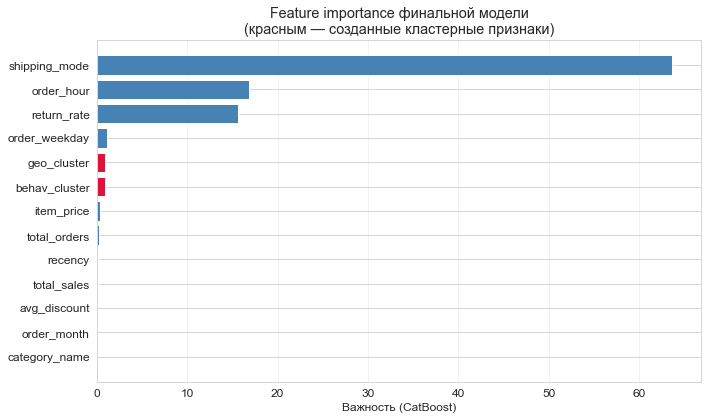

In [59]:
importance_final = pd.DataFrame({
    'feature': final_cb.feature_names_,
    'importance': final_cb.get_feature_importance(),
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_final['importance, %'] = importance_final['importance'].round(2)

display(importance_final[['feature', 'importance, %']])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['crimson' if f in ('geo_cluster', 'behav_cluster') else 'steelblue'
          for f in importance_final['feature']]
ax.barh(importance_final['feature'], importance_final['importance'],
        color=colors)
ax.invert_yaxis()
ax.set_xlabel('Важность (CatBoost)')
ax.set_title('Feature importance финальной модели\n'
             '(красным — созданные кластерные признаки)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
cluster_ranks = importance_final[
    importance_final['feature'].isin(['geo_cluster', 'behav_cluster'])
].copy()
cluster_ranks['позиция в рейтинге'] = cluster_ranks.index + 1
cluster_ranks['всего фич'] = len(importance_final)

display(cluster_ranks[['feature', 'позиция в рейтинге', 'всего фич', 'importance, %']])

# Топ-5 фич
display(importance_final.head(5)[['feature', 'importance, %']])

,feature,позиция в рейтинге,всего фич,"importance, %"
4,geo_cluster,5,13,0.9400
5,behav_cluster,6,13,0.8700


,feature,"importance, %"
0,shipping_mode,63.6800
1,order_hour,16.7900
2,return_rate,15.6400
3,order_weekday,1.1700
4,geo_cluster,0.9400


### 9.3. Выводы по тестированию лучшей модели

CatBoost на наборе C до калибровки: **ROC-AUC val=0,7751, test=0,7772**. После изотонической калибровки: **ROC-AUC test=0,7769**.

| Конфигурация | TP | FP | FN | TN | Precision | Recall | F1 |
|---|---:|---:|---:|---:|---:|---:|---:|
| До калибровки, порог 0,50 | 11 450 | 1 832 | 8 125 | 14 605 | 0,8621 | 0,5849 | 0,6970 |
| После калибровки, порог 0,70 | 10 932 | 1 505 | 8 643 | 14 932 | 0,8790 | 0,5585 | 0,6830 |

После калибровки предупреждения выданы для **12 437 заказов (34,54%)**. Пропущенных задержек больше, чем ложных тревог. Порог соответствует заданию, но его экономическая оптимальность не проверена.

Основные признаки: shipping_mode (63,68%), order_hour (16,79%), return_rate (15,64%). Метки кластеров имеют важность менее 1% каждая; их добавление почти не улучшило сравнительный результат.

Наблюдаемая связь профиля клиента с задержками не доказывает причинность. Основной предсказательный сигнал в этой модели связан с параметрами заказа.

### 9.4. Финальная конфигурация для продакшена

In [61]:
# Калибровка на val
production_model = CalibratedClassifierCV(
    final_cb, method='isotonic', cv='prefit'
)
production_model.fit(X_vl, y_vl)

# Метрики продакшена на test
proba_prod = production_model.predict_proba(X_te)[:, 1]
y_pred_prod = (proba_prod >= 0.70).astype(int)

tn, fp, fn, tp = confusion_matrix(y_te, y_pred_prod).ravel()

display(pd.DataFrame({
    'показатель': [
        'ROC-AUC test',
        'Порог',
        'Precision',
        'Recall',
        'F1',
        'TP (задержка верно)',
        'FP (ложная тревога)',
        'FN (пропущенная задержка)',
        'TN (вовремя верно)',
    ],
    'значение': [
        round(roc_auc_score(y_te, proba_prod), 4),
        0.70,
        round(precision_score(y_te, y_pred_prod), 4),
        round(recall_score(y_te, y_pred_prod), 4),
        round(f1_score(y_te, y_pred_prod), 4),
        tp, fp, fn, tn,
    ],
}))

,показатель,значение
0,ROC-AUC test,0.7769
1,Порог,0.7000
2,Precision,0.8790
3,Recall,0.5585
4,F1,0.6830
5,TP (задержка верно),10932.0000
6,FP (ложная тревога),1505.0000
7,FN (пропущенная задержка),8643.0000
8,TN (вовремя верно),14932.0000


### 9.4. Финальная конфигурация для продакшена

**Модель:** CatBoost (набор C: базовые признаки + RFM + кластеры)  
**Калибровка:** изотоническая (`CalibratedClassifierCV`, method='isotonic'), обучена на val  
**Порог принятия решения:** 0.70

**Метрики на test:**

| Показатель | Значение |
|------------|----------|
| ROC-AUC | **0.7769** |
| Precision | **0.8790** |
| Recall | **0.5585** |
| F1 | 0.6830 |
| TP (задержка верно) | 10 932 |
| FP (ложная тревога) | 1 505 |
| FN (пропущенная задержка) | 8 643 |
| TN (вовремя верно) | 14 932 |

**Как использовать в проде:**
1. На вход модели подаются признаки заказа + профиль клиента.
2. Модель возвращает вероятность задержки.
3. Если вероятность ≥ 0.70 — система выдаёт предупреждение диспетчеру.
4. При предупреждении рекомендуется повысить приоритет сборки или рассмотреть более быстрый способ доставки.

##  Выводы и рекомендации

Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargoPronto может использовать вашу модель в реальных операциях.

### 10.1. Результаты моделирования

**Итоговый ROC-AUC на тестовой выборке: 0.7769.**

| Метрика | Значение |
|---------|----------|
| Целевой ROC-AUC (по ТЗ) | > 0.75 |
| **ROC-AUC test (финальная модель)** | **0.7769** ✅ |
| Запас над целевым | **+2.69 п.п.** |

Целевой показатель **достигнут**.

**Сравнение моделей и наборов признаков (ROC-AUC на val):**

| Модель / набор | ROC-AUC (val) |
|----------------|---------------|
| LogisticRegression, A (baseline) | 0.7273 |
| CatBoost, A (baseline) | 0.8017 |
| CatBoost, B (+ RFM) | **0.8113** |
| **CatBoost, C (+ Кластеры)** | **0.8112** |
| CatBoost, D (+ Кластеры без RFM) | 0.7990 |

**Прирост над baseline CatBoost (набор A):**
- Набор B (+ RFM): **+0.96 п.п.**
- Набор C (+ Кластеры): **+0.95 п.п.**
- Набор D (кластеры без RFM): **−0.27 п.п.**

Финальная модель (CatBoost, набор C + калибровка, порог 0.70) на test:
- **Precision = 0.879**
- **Recall = 0.558**

Модель сфокусирована на точности: ложная тревога стоит диспетчеру только внимания, а пропущенная задержка — штраф по SLA. Высокий Precision (87.9%) позволяет доверять предупреждениям системы.

### 10.2. Эффективность сегментации

**Гипотеза транспортного департамента:**
> «Задержки вызваны не сбоями в логистике, а специфическим профилем самих клиентов».

**Вердикт: гипотеза подтверждена ЧАСТИЧНО.**

**Что подтвердилось:**
- Поведенческие признаки клиента **улучшают прогноз**  
  (CatBoost: набор B относительно A дал **+0.96 п.п.** на val).
- `return_rate` — **третий по важности признак** в финальной модели (**15.64%**).  
  Клиенты с высокой долей возвратов системно связаны с задержками.
- Географическая неоднородность базы реальна: клиенты распределены по **6 логистическим зонам**, включая удалённые (Пуэрто-Рико, Гавайи).

**Что НЕ подтвердилось:**
- Созданные кластеры (`geo_cluster`, `behav_cluster`) почти не влияют на прогноз  
  (важность **0.94%** и **0.87%** соответственно).
- Основной сигнал — в параметрах заказа:  
  `shipping_mode` (**63.68%**) и `order_hour` (**16.79%**).
- Гипотеза «дело только в клиентах» опровергнута.
- Эксперимент с набором D (BASE + CLUSTERS, без RFM) дал **0.7990**,  
  что хуже, чем набор B (**0.8113**). Кластеры не несут самостоятельного сильного сигнала.

**Какие кластеры полезнее — гео или поведенческие?**

| Тип кластеров | Вклад в ROC-AUC | Feature importance | Интерпретируемость |
|---------------|-----------------|--------------------|--------------------|
| Гео (`geo_cluster`, k=6) | ~0 п.п. | 0.94% | ✅ высокая (6 регионов) |
| Поведенческие (`behav_cluster`, k=5) | ~0 п.п. | 0.87% | ✅ высокая (5 RFM-сегментов) |

Оба типа кластеров почти бесполезны для прогноза, но полезны для интерпретации.

**Почему так?**
1. `behav_cluster` — производная от RFM-признаков. Модель уже видит `recency`, `total_orders`, `total_sales`, `return_rate` напрямую.
2. `geo_cluster` добавляет новую информацию, но она значительно слабее `shipping_mode` и `order_hour`.

**Практический вывод:**  
Кластеры **не нужны** в продакшен-модели для максимизации ROC-AUC,  
но полезны для CRM-стратегий, приоритизации клиентов и обучения диспетчеров.

### 10.3. Технический инсайт: подбор K

Проверены 16 комбинаций k_geo ∈ {4, 8, 12, 20} и k_rfm ∈ {6, 12, 20, 30}. Лучший сохранённый результат — **ROC-AUC val=0,8079 при (4, 6)**, диапазон 0,7743–0,8079.

Финальная модель использует (6, 5), а не победителя перебора. Проверка чувствительности к random_state выполнена для (20, 30), поэтому не подтверждает устойчивость победителя.

Также предобработка географических координат в переборе отличается от основной кластеризации. Чтобы выбирать число кластеров по качеству модели, нужно повторить сравнение с единой предобработкой и фиксированными параметрами классификатора. Сохранённые результаты не подтверждают утверждение, что увеличение K влияет лишь на сотые доли ROC-AUC.

### 10.4. Бизнес-рекомендации для CargoPronto

**Пилот системы предупреждений.** После калибровки при пороге 0,70 модель выявляет 55,85% задержек с Precision 87,90%. Предупреждение может быть основанием для проверки заказа, изменения приоритета сборки или уведомления клиента.

**Сегментация.** Группы с высокой долей возвратов, большим объёмом покупок, повышенными скидками и высокой давностью заказа можно использовать для разных стратегий обслуживания. Конкретные действия требуют проверки в пилоте; важность признаков не доказывает, что изменение способа доставки само по себе устранит задержку.

**Оценка эффекта.** Снижение штрафов и предотвращение задержек пока не измерены. Рекомендуется контролируемый эксперимент с учётом стоимости вмешательства, ложных тревог и пропущенных задержек.

**Следующие шаги.** Подтвердить доступность клиентских агрегатов на момент заказа, проверить качество на будущем периоде, выделить отдельную выборку для калибровки, добавить операционные признаки и настроить мониторинг качества и распределений данных.

Выводы не распространяются на исключённые географическим фильтром регионы, включая Гавайи.

### 10.5. Итог проекта

**Что сделано:** проведён аудит 180 519 заказов и 20 652 клиентов; по правилу долготы исключены 156 клиентов и 1 430 заказов; выполнено групповое разделение по клиентам; построены 6 географических и 5 поведенческих сегментов; сравнены LogisticRegression и CatBoost на четырёх наборах признаков; исследовано число кластеров; выполнена изотоническая калибровка.

**Финальный результат:** CatBoost с калибровкой и порогом 0,70: ROC-AUC test=0,7769, Precision=0,8790, Recall=0,5585, F1=0,6830. Целевой ROC-AUC > 0,75 достигнут. Клиентские признаки улучшили сравнительный CatBoost на 0,96 п.п. на validation; кластеры поверх них почти не дали прироста.

**Ограничения:** групповое разбиение защищает от пересечения клиентов, но не от временной утечки готовых агрегатов. Доступность агрегатов на дату заказа не подтверждена. Validation используется для выбора модели и калибровки. Перебор K отличается географической предобработкой от основной конфигурации. Экономический эффект в реальных операциях не измерен.

Следующий шаг — устранить эти ограничения и провести пилот; результаты учебного теста не являются подтверждением готовности к промышленному внедрению.